# Aquamosh (1998) — Anatomía Computacional de un Álbum Cuadrilingüe

**Plastilina Mosh — Aquamosh** · EMI México / Capitol Records · 30 de junio de 1998
Producido por **Tom Rothrock & Rob Schnapf** (los mismos de *Odelay* de Beck y Foo Fighters).

---

## Tesis central

> *Aquamosh* fue un éxito porque resolvió un problema cultural específico de 1998:
> cómo sonar global sin renunciar a lo local. La elección de cuatro idiomas
> (español, inglés, francés, japonés), el equipo productor anglófono, y los
> géneros mezclados no son accidentes — son una estrategia.

Este notebook intenta **confirmar o refutar** esa tesis con datos: letras desde
Genius, comentarios desde YouTube, crítica especializada, y dos modelos de
embedding independientes (OpenAI + Gemini) que se chequean entre sí.

Si los datos dicen otra cosa, el notebook lo reporta sin maquillaje.

---

## Mapa

0. **Entorno y APIs** — Python 3.13, cache en disco, costos estimados
1. **Recolección** — Genius (letras) + crítica especializada (scraping)
2. **Embeddings** — OpenAI `text-embedding-3-large` (3072 dims)
3. **Anatomía multilingüe** — ¿qué dice cada idioma? Chi-cuadrado idioma × campo semántico
4. **Recepción crítica** — análisis estructurado de las reseñas
5. **Semantic axes** — mapa cultural 2D (Monterrey↔LA, emoción↔ironía, 1998↔retro)
6. **Robustez por dimensión** — re-embeddear a 256/512/1024 dims, ¿se preserva el ranking?
7. ~~Drift temporal~~ — omitido (sin YouTube)
8. **Síntesis crítica** — GPT-4o lee todos los hallazgos y escribe la conclusión
9. **Outputs para el blog** — figuras, HTML interactivos, JSON de hallazgos

> **Notas de adaptación**:
> - Plan original: Claude + Gemini + YouTube + Reddit.
> - Realidad del entorno: **YouTube API bloqueada** a nivel del proyecto GCP del usuario,
>   **Gemini key expirada**, sin Anthropic ni Reddit credentials.
> - Pivote: OpenAI (`text-embedding-3-large` + `gpt-4o-mini` para clasificación
>   semántica + `gpt-4o` para la síntesis). La sección 6 fue redefinida como
>   *robustez por dimensión* (matryoshka), que es un test interesante por sí mismo:
>   ¿el análisis sigue siendo consistente si reducimos los embeddings de 3072 → 256 dims?


## 0 · Entorno Python 3.13

**Pregunta que esta sección responde:** ¿está el entorno listo para correr el
análisis sin fallar a la mitad por una dependencia faltante o una versión
incompatible?

**Qué esperar si todo va bien:** una línea por dependencia diciendo `OK`, y un
sello de Python 3.13+ al final.


In [1]:
# pip install skipped — entorno ya provisionado
print('Skipping pip install — assume environment is ready.')


Skipping pip install — assume environment is ready.


In [2]:
# Verificación de versión de Python
import sys
assert sys.version_info >= (3, 13), f"Requiere Python 3.13+, tienes {sys.version}"
print(f"Python {sys.version.split()[0]} — OK")


Python 3.13.2 — OK


In [3]:
# Verificación de imports críticos. Cada falla es informativa, no fatal.
import importlib
CRITICAL = [
    "lyricsgenius", "googleapiclient", "google.generativeai", "openai",
    "sentence_transformers", "umap", "sklearn", "pandas", "numpy",
    "plotly", "matplotlib", "seaborn", "langdetect", "requests", "bs4",
    "tqdm", "scipy", "pyarrow", "bertopic",
]
ok, missing = [], []
for pkg in CRITICAL:
    try:
        importlib.import_module(pkg)
        ok.append(pkg)
    except ImportError as e:
        missing.append((pkg, str(e)))

print(f"Disponibles ({len(ok)}): {', '.join(ok)}")
if missing:
    print(f"Faltan ({len(missing)}):")
    for p, e in missing:
        print(f"   - {p}: {e}")
else:
    print("Todos los imports críticos resueltos.")

# hdbscan fallback para Python 3.13 si no compila
try:
    from hdbscan import HDBSCAN  # type: ignore
    HDBSCAN_SRC = "hdbscan"
except Exception:
    from sklearn.cluster import HDBSCAN  # type: ignore
    HDBSCAN_SRC = "sklearn.cluster"
print(f"HDBSCAN proviene de: {HDBSCAN_SRC}")


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/importlib/__init__.py:88: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  return _bootstrap._gcd_import(name[level:], package, level)


Disponibles (19): lyricsgenius, googleapiclient, google.generativeai, openai, sentence_transformers, umap, sklearn, pandas, numpy, plotly, matplotlib, seaborn, langdetect, requests, bs4, tqdm, scipy, pyarrow, bertopic
Todos los imports críticos resueltos.
HDBSCAN proviene de: hdbscan


## 0.1 · APIs, cache y costos

**Pregunta:** ¿Tenemos las credenciales? ¿Cuánto va a costar correr esto?

Cache en disco obligatorio: ninguna API se llama dos veces en la misma sesión.
Esto hace el notebook reproducible y barato. La clave determina formato:
- `*.json` → dict/list
- `*.parquet` → DataFrame
- `*.npy` → numpy array
- `*.pkl` → cualquier otra cosa


In [4]:
import os, json, pickle
from pathlib import Path
from typing import Any
from datetime import datetime

# Cargar .env si existe
try:
    from dotenv import load_dotenv
    for parent in [Path.cwd(), *Path.cwd().parents][:5]:
        envp = parent / ".env"
        if envp.exists():
            load_dotenv(envp)
            print(f".env cargado desde {envp}")
            break
except ImportError:
    pass

def _first(*names: str) -> str | None:
    for n in names:
        v = os.environ.get(n)
        if v:
            return v
    return None

API = {
    "genius":   _first("GENIUS_TOKEN", "GENIUS_API_TOKEN"),
    "openai":   _first("OPENAI_API_KEY"),
    "gemini":   _first("GEMINI_API_KEY", "GEMINI_API"),
    "youtube":  _first("YOUTUBE_API_KEY", "YOUTUBE_API"),
    "anthropic": _first("ANTHROPIC_API_KEY"),
    "reddit_id": _first("REDDIT_CLIENT_ID"),
    "reddit_sec": _first("REDDIT_CLIENT_SECRET"),
}

print("Estado de APIs:")
for k, v in API.items():
    status = "presente" if v else "ausente"
    print(f"  {k:12s} {status}")

REQUIRED = ["genius", "openai", "gemini", "youtube"]
missing = [k for k in REQUIRED if not API[k]]
if missing:
    print(f"\nFALTAN: {missing} — las secciones que las usan fallarán graciosamente.")
else:
    print("\nTodas las APIs requeridas están disponibles.")


.env cargado desde /Users/carlosdaniel/Documents/Blog/carlosjimenez88m.github.io/.env
Estado de APIs:
  genius       presente
  openai       presente
  gemini       presente
  youtube      presente
  anthropic    ausente
  reddit_id    ausente
  reddit_sec   ausente

Todas las APIs requeridas están disponibles.


In [5]:
import numpy as np
import pandas as pd

class CacheManager:
    # Persistencia para resultados de API y cómputos costosos.
    # Extensión del key determina el formato:
    # .json -> JSON, .parquet -> DataFrame, .npy -> ndarray, resto -> pickle.

    def __init__(self, base: str | Path = "data"):
        self.base = Path(base)
        for sub in ["raw", "processed", "embeddings"]:
            (self.base / sub).mkdir(parents=True, exist_ok=True)
        for sub in ["outputs/figures", "outputs/html", "outputs/exports"]:
            Path(sub).mkdir(parents=True, exist_ok=True)

    def _path(self, key: str) -> Path:
        p = self.base / key
        p.parent.mkdir(parents=True, exist_ok=True)
        return p

    def exists(self, key: str) -> bool:
        return self._path(key).exists()

    def get(self, key: str) -> Any | None:
        p = self._path(key)
        if not p.exists():
            return None
        if key.endswith(".json"):
            return json.loads(p.read_text(encoding="utf-8"))
        if key.endswith(".parquet"):
            return pd.read_parquet(p)
        if key.endswith(".npy"):
            return np.load(p, allow_pickle=False)
        if key.endswith((".txt", ".html", ".md")):
            return p.read_text(encoding="utf-8", errors="replace")
        with p.open("rb") as f:
            return pickle.load(f)

    def set(self, key: str, value: Any) -> None:
        p = self._path(key)
        if key.endswith(".json"):
            p.write_text(json.dumps(value, ensure_ascii=False, indent=2,
                                    default=str), encoding="utf-8")
        elif key.endswith(".parquet"):
            value.to_parquet(p, index=False)
        elif key.endswith(".npy"):
            np.save(p, value, allow_pickle=False)
        elif key.endswith((".txt", ".html", ".md")):
            p.write_text(str(value), encoding="utf-8")
        else:
            with p.open("wb") as f:
                pickle.dump(value, f)

cache = CacheManager("data")
print(f"Cache en {cache.base.resolve()}")


Cache en /Users/carlosdaniel/Documents/Blog/carlosjimenez88m.github.io/tidytuesday/aquamosh-analysis/data


In [6]:
COST_ESTIMATES = {
    "openai_embeddings":  "~$0.004  (12 letras + comentarios YouTube)",
    "gemini_embeddings":  "~$0.001  (tier gratuito cubre la mayoría)",
    "gemini_2_5_pro":     "~$0.20-0.40 (clasificación + síntesis)",
    "youtube_api":        "Gratis (free tier diario)",
    "genius_api":         "Gratis",
}
print("Estimación de costos antes de correr el notebook completo:")
for k, v in COST_ESTIMATES.items():
    print(f"  {k:22s} -> {v}")
print("\nTotal estimado: <$1 USD para el run completo desde cero.")
print("Con cache caliente, los re-runs son gratis.")


Estimación de costos antes de correr el notebook completo:
  openai_embeddings      -> ~$0.004  (12 letras + comentarios YouTube)
  gemini_embeddings      -> ~$0.001  (tier gratuito cubre la mayoría)
  gemini_2_5_pro         -> ~$0.20-0.40 (clasificación + síntesis)
  youtube_api            -> Gratis (free tier diario)
  genius_api             -> Gratis

Total estimado: <$1 USD para el run completo desde cero.
Con cache caliente, los re-runs son gratis.


## 1 · Recolección de datos

**Pregunta:** ¿podemos construir un corpus suficiente sobre Aquamosh — letras +
recepción — sin intervención manual?

**Qué esperar:** 12 letras desde Genius, métricas de YouTube para los 12 tracks,
2,000–6,000 comentarios totales, y al menos 2 reseñas críticas scrapeadas.


In [7]:
# Tracklist oficial canónico
TRACKLIST: list[dict] = [
    {"num":  1, "title": "Niño Bomba",        "duration": "3:43", "note": "samplea The Meters"},
    {"num":  2, "title": "Afroman",            "duration": "3:38", "note": "en True Crime"},
    {"num":  3, "title": "Ode to Mauricio Garcés", "duration": "4:14", "note": "bossa / acid jazz"},
    {"num":  4, "title": "Banano's Bar",       "duration": "5:48", "note": "samplea East & West"},
    {"num":  5, "title": "Monster Truck",      "duration": "4:18", "note": "prod. Sukia"},
    {"num":  6, "title": "Encendedor",         "duration": "2:36", "note": "samplea Minutemen"},
    {"num":  7, "title": "Bungaloo Punta Cometa", "duration": "3:59", "note": "prod. Café Tacuba"},
    {"num":  8, "title": "Aquamosh",           "duration": "3:56", "note": "track título"},
    {"num":  9, "title": "I've Got That Milton Pacheco Kinda' Feeling", "duration": "4:22", "note": "homenaje"},
    {"num": 10, "title": "Pornoshop",          "duration": "3:31", "note": ""},
    {"num": 11, "title": "Savage Sucker Boy",  "duration": "3:32", "note": ""},
    {"num": 12, "title": "Mr. P. Mosh",        "duration": "4:21", "note": ""},
]
PLAYLIST_ID = "PLgaIh8xDn6aOqRsImDJ1QlWX5C0AoO60b"

df_tracks = pd.DataFrame(TRACKLIST)
print(f"Tracklist canónico: {len(df_tracks)} tracks")
df_tracks


Tracklist canónico: 12 tracks


,num,title,duration,note
0,1,Niño Bomba,3:43,samplea The Meters
1,2,Afroman,3:38,en True Crime
2,3,Ode to Mauricio Garcés,4:14,bossa / acid jazz
3,4,Banano's Bar,5:48,samplea East & West
4,5,Monster Truck,4:18,prod. Sukia
5,6,Encendedor,2:36,samplea Minutemen
6,7,Bungaloo Punta Cometa,3:59,prod. Café Tacuba
7,8,Aquamosh,3:56,track título
8,9,I've Got That Milton Pacheco Kinda' Feeling,4:22,homenaje
9,10,Pornoshop,3:31,


### 1.1 — Letras desde Genius

In [8]:
import re, time
from typing import Optional
from tqdm.auto import tqdm

try:
    import lyricsgenius
    GENIUS_OK = True
except ImportError:
    GENIUS_OK = False
    print("lyricsgenius no instalado")

def clean_lyrics(raw: str) -> str:
    # Quita headers [Verse], contributor lines y vacíos múltiples sin lematizar.
    if not raw:
        return ""
    raw = re.sub(r"^\d+ Contributors?.*?Lyrics", "", raw, flags=re.DOTALL)
    raw = re.sub(r"\[[^\]]+\]", "", raw)
    raw = re.sub(r"(?i)you might also like.*", "", raw)
    raw = re.sub(r"\n{3,}", "\n\n", raw)
    return raw.strip()

def fetch_lyrics_genius(genius_token, tracks):
    rows = []
    if not (GENIUS_OK and genius_token):
        print("Genius no disponible — DataFrame vacío")
        return pd.DataFrame(rows)

    g = lyricsgenius.Genius(
        genius_token, remove_section_headers=True,
        verbose=False, timeout=15, retries=3, skip_non_songs=True,
    )

    for t in tqdm(tracks, desc="Genius"):
        ck = f"raw/lyrics_{t['num']:02d}.json"
        if cache.exists(ck):
            rows.append(cache.get(ck))
            continue

        title = t["title"]
        song = None
        variants = [title, title.replace("ñ", "n"),
                    title.split(":")[0], title.split("'")[0]]
        for variant in variants:
            try:
                song = g.search_song(variant, "Plastilina Mosh")
                if song and song.lyrics:
                    break
            except Exception as e:
                print(f"  ! {variant}: {e}")
                time.sleep(2)

        if not song or not song.lyrics:
            row = {"track_num": t["num"], "title": title,
                   "lyrics_raw": "", "lyrics_clean": "",
                   "genius_url": "", "word_count": 0, "char_count": 0,
                   "found": False}
        else:
            clean = clean_lyrics(song.lyrics)
            row = {"track_num": t["num"], "title": title,
                   "lyrics_raw": song.lyrics, "lyrics_clean": clean,
                   "genius_url": getattr(song, "url", ""),
                   "word_count": len(clean.split()),
                   "char_count": len(clean),
                   "found": True}
        cache.set(ck, row)
        rows.append(row)
        time.sleep(0.5)

    return pd.DataFrame(rows).sort_values("track_num").reset_index(drop=True)

df_lyrics = fetch_lyrics_genius(API["genius"], TRACKLIST)
found = df_lyrics["found"].sum() if "found" in df_lyrics.columns else 0
print(f"\nLetras recuperadas: {found}/{len(TRACKLIST)}")
if found < 9:
    print("Menos de 9 letras: el análisis multilingüe perderá poder estadístico.")
df_lyrics[["track_num","title","word_count","found"]] if not df_lyrics.empty else df_lyrics


Genius:   0%|          | 0/12 [00:00<?, ?it/s]


Letras recuperadas: 10/12


,track_num,title,word_count,found
0,1,Niño Bomba,341,True
1,2,Afroman,431,True
2,3,Ode to Mauricio Garcés,0,False
3,4,Banano's Bar,184,True
4,5,Monster Truck,324,True
5,6,Encendedor,0,False
6,7,Bungaloo Punta Cometa,254,True
7,8,Aquamosh,60,True
8,9,I've Got That Milton Pacheco Kinda' Feeling,73,True
9,10,Pornoshop,74,True


In [9]:
def lyrics_to_lines(df):
    rows = []
    for _, r in df.iterrows():
        if not r.get("lyrics_clean"):
            continue
        for i, line in enumerate(r["lyrics_clean"].split("\n")):
            line = line.strip()
            if len(line) < 2 or re.fullmatch(r"[\W_]+", line):
                continue
            rows.append({
                "track_num": r["track_num"], "title": r["title"],
                "line_num": i, "line_text": line,
                "line_len": len(line.split()),
            })
    return pd.DataFrame(rows)

df_lines = lyrics_to_lines(df_lyrics) if not df_lyrics.empty else pd.DataFrame()
print(f"Total de líneas analizables: {len(df_lines)}")
if not df_lines.empty:
    print(df_lines.groupby("title")["line_num"].count().rename("n_lines"))


Total de líneas analizables: 392
title
Afroman                                        114
Aquamosh                                        15
Banano's Bar                                    30
Bungaloo Punta Cometa                           41
I've Got That Milton Pacheco Kinda' Feeling     12
Monster Truck                                   38
Mr. P. Mosh                                     51
Niño Bomba                                      35
Pornoshop                                       19
Savage Sucker Boy                               37
Name: n_lines, dtype: int64


### 1.2 — YouTube: playlist + métricas + comentarios

**Estado real:** la API key `YOUTUBE_API` del usuario tiene **bloqueado el servicio
YouTube Data API v3** a nivel del proyecto de Google Cloud (HTTP 403 en todos los
endpoints). Para activarla:
*Google Cloud Console → APIs & Services → Enable "YouTube Data API v3"*, o
quitar restricciones del API key.

Mientras tanto, esta sección crea DataFrames vacíos y todas las celdas posteriores
los manejan graciosamente. El análisis del álbum no depende de YouTube: la
multilingüe + la crítica + los axes son auto-suficientes.


In [10]:
# Probe rápido: ¿está YouTube Data API v3 habilitado para esta key?
df_yt_playlist = pd.DataFrame()
df_youtube = pd.DataFrame()
emb_oai_yt = np.array([]) if "np" in dir() else None

YT_AVAILABLE = False
if API["youtube"]:
    try:
        from googleapiclient.discovery import build
        from googleapiclient.errors import HttpError
        yt_test = build("youtube", "v3", developerKey=API["youtube"], cache_discovery=False)
        yt_test.videos().list(id="dQw4w9WgXcQ", part="snippet").execute()
        YT_AVAILABLE = True
        print("YouTube Data API v3 responde correctamente.")
    except Exception as e:
        msg = str(e)[:240]
        if "blocked" in msg or "403" in msg:
            print("YouTube Data API v3 está BLOQUEADA para esta key.")
            print("  -> habilitar en GCP Console > APIs & Services > YouTube Data API v3")
        else:
            print(f"YouTube probe falló: {msg}")
else:
    print("Sin YOUTUBE_API en .env — saltando YouTube.")


YouTube Data API v3 está BLOQUEADA para esta key.
  -> habilitar en GCP Console > APIs & Services > YouTube Data API v3


In [11]:
# Las funciones de YouTube se conservan para cuando la API funcione,
# pero la ejecución se gobierna por el flag YT_AVAILABLE.
try:
    from googleapiclient.discovery import build
    from googleapiclient.errors import HttpError
    YT_OK = True
except ImportError:
    YT_OK = False

def yt_client():
    if not (YT_OK and API["youtube"] and YT_AVAILABLE):
        return None
    return build("youtube", "v3", developerKey=API["youtube"], cache_discovery=False)

def fetch_playlist_videos(playlist_id):
    ck = "raw/youtube_playlist.parquet"
    if cache.exists(ck):
        return cache.get(ck)

    yt = yt_client()
    if not yt:
        print("YouTube no disponible")
        return pd.DataFrame()

    items, token = [], None
    while True:
        resp = yt.playlistItems().list(
            playlistId=playlist_id, part="snippet,contentDetails",
            maxResults=50, pageToken=token,
        ).execute()
        items.extend(resp.get("items", []))
        token = resp.get("nextPageToken")
        if not token:
            break

    rows = []
    for it in items:
        sn = it["snippet"]
        rows.append({
            "video_id": sn["resourceId"]["videoId"],
            "title": sn["title"],
            "position": sn["position"],
            "published_at": sn.get("publishedAt"),
        })

    ids = [r["video_id"] for r in rows]
    stats_map = {}
    for i in range(0, len(ids), 50):
        chunk = ids[i:i+50]
        resp = yt.videos().list(id=",".join(chunk), part="statistics,snippet").execute()
        for v in resp.get("items", []):
            st = v.get("statistics", {})
            stats_map[v["id"]] = {
                "view_count":    int(st.get("viewCount", 0)),
                "like_count":    int(st.get("likeCount", 0)),
                "comment_count": int(st.get("commentCount", 0)),
                "video_published": v["snippet"].get("publishedAt"),
            }
    for r in rows:
        r.update(stats_map.get(r["video_id"], {}))

    df = pd.DataFrame(rows)
    cache.set(ck, df)
    return df

if YT_AVAILABLE:
    df_yt_playlist = fetch_playlist_videos(PLAYLIST_ID)
    print(f"Videos en playlist: {len(df_yt_playlist)}")
else:
    print("Saltando playlist (YouTube no disponible).")
df_yt_playlist[["title", "view_count", "like_count", "comment_count"]] if not df_yt_playlist.empty else df_yt_playlist


Saltando playlist (YouTube no disponible).


""


In [12]:
from difflib import SequenceMatcher

def match_track(yt_title, tracks):
    yt_norm = yt_title.lower()
    best, best_score = None, 0.0
    for t in tracks:
        s = SequenceMatcher(None, yt_norm, t["title"].lower()).ratio()
        if s > best_score:
            best, best_score = t["num"], s
    return best if best_score >= 0.55 else None

if not df_yt_playlist.empty:
    df_yt_playlist["track_num"] = df_yt_playlist["title"].apply(
        lambda x: match_track(x, TRACKLIST)
    )
    matched = df_yt_playlist["track_num"].notna().sum()
    print(f"Videos empatados con tracklist: {matched}/{len(df_yt_playlist)}")
    df_yt_playlist[["title", "track_num", "view_count"]]
else:
    print("Sin playlist de YouTube — saltando empate de tracks.")


Sin playlist de YouTube — saltando empate de tracks.


In [13]:
import time as _t

def fetch_comments_for_video(video_id, max_comments=500):
    yt = yt_client()
    if not yt:
        return []
    rows, token = [], None
    while len(rows) < max_comments:
        try:
            resp = yt.commentThreads().list(
                videoId=video_id, part="snippet",
                order="relevance", maxResults=100, pageToken=token,
                textFormat="plainText",
            ).execute()
        except HttpError as e:
            print(f"  ! {video_id}: HTTP {e.resp.status}")
            break
        for it in resp.get("items", []):
            sn = it["snippet"]["topLevelComment"]["snippet"]
            text = sn.get("textDisplay", "")
            if len(text.split()) < 6:
                continue
            rows.append({
                "comment_id": it["id"],
                "video_id": video_id,
                "text_display": text,
                "author_name": sn.get("authorDisplayName"),
                "like_count": int(sn.get("likeCount", 0)),
                "published_at": sn.get("publishedAt"),
                "updated_at":   sn.get("updatedAt"),
            })
            if len(rows) >= max_comments:
                break
        token = resp.get("nextPageToken")
        if not token:
            break
    return rows

def fetch_all_comments(df_videos):
    ck = "raw/youtube_comments.parquet"
    if cache.exists(ck):
        return cache.get(ck)
    all_rows = []
    for _, v in tqdm(df_videos.iterrows(), total=len(df_videos), desc="YT comments"):
        if pd.isna(v.get("track_num")):
            continue
        rows = fetch_comments_for_video(v["video_id"], max_comments=500)
        track_title = next((t["title"] for t in TRACKLIST
                            if t["num"] == int(v["track_num"])), v["title"])
        for r in rows:
            r["track_num"] = int(v["track_num"])
            r["track_title"] = track_title
        all_rows.extend(rows)
        _t.sleep(0.3)
    df = pd.DataFrame(all_rows)
    if not df.empty:
        df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
        cache.set(ck, df)
    return df

if YT_AVAILABLE and not df_yt_playlist.empty:
    df_youtube = fetch_all_comments(df_yt_playlist)
else:
    df_youtube = pd.DataFrame()
print(f"\nComentarios totales: {len(df_youtube)}")
if not df_youtube.empty:
    print(df_youtube.groupby("track_title")["comment_id"].count().rename("n").sort_values(ascending=False))



Comentarios totales: 0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"axes.facecolor": "#0d0d1a", "figure.facecolor": "#0d0d1a",
                     "axes.edgecolor": "white", "axes.labelcolor": "white",
                     "xtick.color": "white", "ytick.color": "white",
                     "text.color": "white", "axes.titlecolor": "white"})

if not df_youtube.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    df_youtube["track_title"].value_counts().sort_values().plot.barh(
        ax=axes[0], color="#ff6b6b")
    axes[0].set_title("Comentarios por track")
    axes[0].set_xlabel("n")

    by_year = df_youtube.copy()
    by_year["year"] = by_year["published_at"].dt.year
    by_year.groupby("year").size().plot(ax=axes[1], marker="o", color="#4ecdc4")
    axes[1].set_title("Distribución temporal de comentarios")
    axes[1].set_xlabel("año"); axes[1].set_ylabel("n")
    plt.tight_layout()
    plt.savefig("outputs/figures/youtube_corpus_diagnostic.png", dpi=120,
                facecolor="#0d0d1a", bbox_inches="tight")
    plt.show()

    n_years = by_year["year"].nunique()
    if len(df_youtube) < 200:
        print("< 200 comentarios: la validez estadística será débil.")
    if n_years < 3:
        print("< 3 años distintos: la Sección 7 (drift temporal) se saltará.")
    print(f"\n{len(df_youtube)} comentarios | {n_years} años distintos")
else:
    print("Sin comentarios — diagnóstico omitido.")


Sin comentarios — diagnóstico omitido.


### 1.3 — Crítica especializada (scraping con fallback)

In [15]:
import requests
from bs4 import BeautifulSoup

UA = ("Mozilla/5.0 (Macintosh; Intel Mac OS X 14_5) "
      "AppleWebKit/605.1.15 (KHTML, like Gecko) "
      "Version/17.5 Safari/605.1.15")

def fetch_url(url, retries=3, delay=3.0):
    ck = f"raw/critic_{abs(hash(url))}.html"
    if cache.exists(ck):
        return cache.get(ck)
    for attempt in range(retries):
        try:
            r = requests.get(url, headers={"User-Agent": UA}, timeout=15)
            if r.status_code == 200:
                cache.set(ck, r.text)
                _t.sleep(delay)
                return r.text
            print(f"  ! {url} -> HTTP {r.status_code}")
        except Exception as e:
            print(f"  ! {url} attempt {attempt+1}: {e}")
            _t.sleep(delay * (attempt + 1))
    return None

CRITIC_SOURCES = [
    {"source": "AllMusic",
     "url": "https://www.allmusic.com/album/aquamosh-mw0000599576",
     "sel": "div.text, div.review-text, section.review"},
    {"source": "RateYourMusic",
     "url": "https://rateyourmusic.com/release/album/plastilina-mosh/aquamosh/",
     "sel": "div.release_pri_descriptors, div.release_pri_genres, span.rendered_text"},
    {"source": "AlbumOfTheYear",
     "url": "https://www.albumoftheyear.org/album/108643-plastilina-mosh-aqua-mosh.php",
     "sel": "div.albumReview, div.albumScore, div.userReviewText"},
    {"source": "Ink19",
     "url": "https://ink19.com/1998/07/magazine/music-reviews/czuyvl-plastilina-mosh",
     "sel": "article, div.entry-content, div.review-body, p"},
]

critic_rows = []
for src in CRITIC_SOURCES:
    print(f"-> {src['source']}")
    html = fetch_url(src["url"])
    if not html:
        print(f"  Falló — saltando")
        continue
    soup = BeautifulSoup(html, "html.parser")
    nodes = soup.select(src["sel"])
    text = "\n".join(n.get_text(" ", strip=True) for n in nodes if n.get_text(strip=True))
    if not text or len(text) < 80:
        text = "\n".join(p.get_text(" ", strip=True) for p in soup.find_all("p")
                          if len(p.get_text(strip=True)) > 50)
    critic_rows.append({
        "source": src["source"], "url": src["url"],
        "text": text[:8000], "text_length": len(text),
        "score": None, "reviewer": None, "date": None, "language": "en",
    })
    print(f"  {len(text)} chars extraídos")

df_critics = pd.DataFrame(critic_rows)
print(f"\nReseñas con texto: {(df_critics['text_length'] > 200).sum() if not df_critics.empty else 0} de {len(df_critics)}")
df_critics[["source", "text_length"]] if not df_critics.empty else df_critics


-> AllMusic


  187 chars extraídos
-> RateYourMusic


  ! https://rateyourmusic.com/release/album/plastilina-mosh/aquamosh/ -> HTTP 403
  ! https://rateyourmusic.com/release/album/plastilina-mosh/aquamosh/ -> HTTP 403


  ! https://rateyourmusic.com/release/album/plastilina-mosh/aquamosh/ -> HTTP 403
  Falló — saltando
-> AlbumOfTheYear


  805 chars extraídos
-> Ink19


  6764 chars extraídos

Reseñas con texto: 2 de 3


,source,text_length
0,AllMusic,187
1,AlbumOfTheYear,805
2,Ink19,6764


In [16]:
def fetch_discogs(release_id=98687):
    ck = f"raw/discogs_{release_id}.json"
    if cache.exists(ck):
        return cache.get(ck)
    url = f"https://api.discogs.com/releases/{release_id}"
    try:
        r = requests.get(url, headers={"User-Agent": UA + " aquamosh-analysis/1.0"}, timeout=15)
        if r.status_code == 200:
            data = r.json()
            cache.set(ck, data)
            return data
    except Exception as e:
        print(f"Discogs falló: {e}")
    return {}

discogs = fetch_discogs(98687)
if discogs:
    print(f"Discogs release: {discogs.get('title')} ({discogs.get('year')})")
    print(f"  Tracks listados: {len(discogs.get('tracklist', []))}")
    print(f"  Créditos: {len(discogs.get('extraartists', []))}")


Discogs release: Aquamosh (1998)
  Tracks listados: 12
  Créditos: 0


### 1.4 — Reddit (omitido)

El plan original incluía un corpus de Reddit vía PRAW. Este entorno no tiene
`REDDIT_CLIENT_ID` / `REDDIT_CLIENT_SECRET`, así que la sección se omite
explícitamente. El análisis de recepción descansa sobre YouTube + crítica.

In [17]:
df_reddit = pd.DataFrame()
if API["reddit_id"] and API["reddit_sec"]:
    print("Credenciales Reddit detectadas — implementar aquí si se desea expandir corpus")
else:
    print("Reddit omitido — sin credenciales.")


Reddit omitido — sin credenciales.


### 1.5 — Tabla resumen del corpus

In [18]:
def summarize_corpus(dfs):
    rows = []
    for name, df in dfs.items():
        if df is None or df.empty:
            rows.append({"fuente": name, "n_docs": 0,
                         "idioma_dominante": "n/a", "avg_words": 0,
                         "rango_fechas": "n/a"})
            continue
        text_col = next((c for c in ["text", "text_display", "lyrics_clean", "line_text"]
                         if c in df.columns), None)
        if text_col:
            avg = df[text_col].astype(str).str.split().str.len().mean()
        else:
            avg = 0
        date_col = next((c for c in ["published_at", "date"] if c in df.columns), None)
        if date_col and pd.api.types.is_datetime64_any_dtype(df[date_col]):
            rango = f"{df[date_col].min().date()} -> {df[date_col].max().date()}"
        else:
            rango = "n/a"
        rows.append({"fuente": name, "n_docs": len(df),
                     "idioma_dominante": "—", "avg_words": round(float(avg), 1),
                     "rango_fechas": rango})
    return pd.DataFrame(rows)

corpus_summary = summarize_corpus({
    "Letras Genius":  df_lyrics if "df_lyrics" in dir() else pd.DataFrame(),
    "Líneas (granular)": df_lines if "df_lines" in dir() else pd.DataFrame(),
    "YouTube comentarios": df_youtube,
    "Crítica especializada": df_critics,
    "Reddit": df_reddit,
})
print("=" * 60)
print("CORPUS RECOLECTADO")
print("=" * 60)
print(corpus_summary.to_string(index=False))

for _, r in corpus_summary.iterrows():
    if r["fuente"] in ("YouTube comentarios", "Crítica especializada") and r["n_docs"] < 50:
        print(f"\n{r['fuente']}: < 50 docs — análisis estadístico debilitado.")


CORPUS RECOLECTADO
               fuente  n_docs idioma_dominante  avg_words rango_fechas
        Letras Genius      12                —      191.4          n/a
    Líneas (granular)     392                —        5.9          n/a
  YouTube comentarios       0              n/a        0.0          n/a
Crítica especializada       3                —      407.7          n/a
               Reddit       0              n/a        0.0          n/a

YouTube comentarios: < 50 docs — análisis estadístico debilitado.

Crítica especializada: < 50 docs — análisis estadístico debilitado.


## 2 · Embeddings duales — OpenAI + Gemini

**Pregunta:** ¿el análisis cambia si lo hacemos con OpenAI vs Gemini? Si los dos
modelos coinciden, las conclusiones son robustas; si discrepan, eso *también*
es información — nos dice dónde está la subjetividad del modelo.

Embeddings generados:
- A) Letras completas por track (12)
- B) Letras línea por línea
- C) Comentarios YouTube
- D) Reseñas críticas


In [19]:
import numpy as np

def chunked(seq, n=100):
    seq = list(seq)
    for i in range(0, len(seq), n):
        yield seq[i:i+n]

def openai_embed(texts, model="text-embedding-3-large", dims=3072):
    if not API["openai"] or not texts:
        return np.zeros((len(texts), dims), dtype=np.float32)
    from openai import OpenAI
    client = OpenAI(api_key=API["openai"])
    out = []
    for batch in tqdm(list(chunked(texts, 100)), desc="OpenAI embed"):
        for attempt in range(3):
            try:
                resp = client.embeddings.create(model=model, input=batch)
                out.extend([d.embedding for d in resp.data])
                break
            except Exception as e:
                wait = 2 ** attempt
                print(f"  retry {attempt+1} in {wait}s: {e}")
                _t.sleep(wait)
        else:
            out.extend([[0.0]*dims for _ in batch])
    return np.array(out, dtype=np.float32)

def gemini_embed(texts, model="gemini-embedding-001"):
    if not API["gemini"] or not texts:
        return np.zeros((len(texts), 3072), dtype=np.float32)
    import google.generativeai as genai
    genai.configure(api_key=API["gemini"])
    out = []
    for t in tqdm(texts, desc="Gemini embed"):
        for attempt in range(3):
            try:
                r = genai.embed_content(model=f"models/{model}", content=t,
                                         task_type="SEMANTIC_SIMILARITY")
                out.append(r["embedding"])
                break
            except Exception:
                _t.sleep(2 ** attempt)
        else:
            out.append([0.0]*3072)
        _t.sleep(0.05)
    return np.array(out, dtype=np.float32)

def embed_with_cache(texts, key, provider="openai"):
    if cache.exists(key):
        return cache.get(key)
    fn = openai_embed if provider == "openai" else gemini_embed
    arr = fn(texts)
    cache.set(key, arr)
    return arr

print("Funciones de embedding listas (OpenAI + Gemini, con cache).")


Funciones de embedding listas (OpenAI + Gemini, con cache).


In [20]:
# A) Letras completas por track — solo OpenAI
# (la Gemini key del .env está expirada; Sección 6 hace robustez por dimensión)
emb_gem_lyrics = np.array([])  # placeholder vacío para retro-compat
if not df_lyrics.empty and df_lyrics["found"].sum() > 0:
    lyrics_texts = df_lyrics.loc[df_lyrics["found"], "lyrics_clean"].tolist()
    emb_oai_lyrics = embed_with_cache(lyrics_texts, "embeddings/openai_lyrics_full.npy", "openai")
    print(f"Letras -> OpenAI: {emb_oai_lyrics.shape}")
else:
    emb_oai_lyrics = np.array([])
    print("Sin letras — embeddings saltados")


Letras -> OpenAI: (10, 3072)


In [21]:
# B) Líneas (granular)
if not df_lines.empty:
    line_texts = df_lines["line_text"].tolist()
    emb_oai_lines = embed_with_cache(line_texts, "embeddings/openai_lyrics_lines.npy", "openai")
    print(f"Líneas -> OpenAI: {emb_oai_lines.shape}")
else:
    emb_oai_lines = np.array([])


Líneas -> OpenAI: (392, 3072)


In [22]:
# C) Comentarios YouTube
if not df_youtube.empty:
    yt_texts = df_youtube["text_display"].astype(str).tolist()
    emb_oai_yt = embed_with_cache(yt_texts, "embeddings/openai_youtube.npy", "openai")
    print(f"YouTube -> OpenAI: {emb_oai_yt.shape}")
else:
    emb_oai_yt = np.array([])


In [23]:
# D) Crítica
if not df_critics.empty:
    crit_texts = df_critics["text"].astype(str).tolist()
    emb_oai_crit = embed_with_cache(crit_texts, "embeddings/openai_critics.npy", "openai")
    print(f"Crítica -> OpenAI: {emb_oai_crit.shape}")
else:
    emb_oai_crit = np.array([])


Crítica -> OpenAI: (3, 3072)


## 3 · Anatomía multilingüe — la pregunta más importante

> En un álbum de 1998 con 4 idiomas (ES/EN/FR/JA) y un equipo productor
> anglófono, **¿qué rol cumple cada idioma?**

**Hipótesis viva:** los idiomas no son equivalentes — están especializados.
Si la hipótesis es cierta, el chi-cuadrado de `idioma × campo semántico`
rechaza la independencia (p < 0.05) y los residuos estandarizados muestran
celdas con asociación fuerte (|z| > 2).


### 3.1 — Detección de idioma por línea

In [24]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

import re as _re
def detect_language(text):
    if not text or len(text.strip()) < 2:
        return "OTHER"
    if _re.search(r"[぀-ヿ一-鿿]", text):
        return "JA"
    try:
        c = detect(text)
    except Exception:
        return "OTHER"
    mapping = {"es": "ES", "en": "EN", "fr": "FR", "ja": "JA"}
    return mapping.get(c, "OTHER")

if not df_lines.empty:
    df_lines["language"] = df_lines["line_text"].apply(detect_language)

    def maybe_mixed(row):
        if len(row["line_text"].split()) < 4:
            return row["language"]
        tokens = row["line_text"].lower().split()
        spanish_markers = {"que","de","la","el","y","en","un","una","con","por","los","las","como"}
        english_markers = {"the","of","and","to","you","i","is","my","in","on","with"}
        french_markers  = {"je","tu","le","la","et","de","les","un","une","ne","pas"}
        sets = {"ES": spanish_markers, "EN": english_markers, "FR": french_markers}
        hits = {lang: len(set(tokens) & m) for lang, m in sets.items()}
        active = [k for k, v in hits.items() if v >= 1]
        if len(active) >= 2:
            return "MIXED"
        return row["language"]

    df_lines["language"] = df_lines.apply(maybe_mixed, axis=1)

    print("Distribución de idiomas por línea:")
    print(df_lines["language"].value_counts())


Distribución de idiomas por línea:
language
EN       107
MIXED    106
ES        89
OTHER     78
FR        12
Name: count, dtype: int64


### 3.2 — Clasificación de campo semántico con Gemini (línea por línea)

Sustituimos Claude por **Gemini 2.5 Flash** para la clasificación (rápido, barato, multilingüe).
Una llamada por track, no por línea, para minimizar costos.

In [25]:
import json as _json
SEMANTIC_FIELDS = ["CUERPO", "MARCA", "LUGAR", "EMOCION",
                   "IDENTIDAD", "ACCION", "REFERENCIA", "NONSENSE"]

CLASSIFY_PROMPT = (
    "Clasifica cada línea con UNO de estos códigos:\n"
    "CUERPO    - fisicalidad, movimiento, sexualidad, sensación\n"
    "MARCA     - productos, marcas comerciales, objetos de consumo\n"
    "LUGAR     - geografía, espacios, ciudades, territorios\n"
    "EMOCION   - estados internos, sentimientos, afecto\n"
    "IDENTIDAD - pertenencia, origen, quién soy/somos\n"
    "ACCION    - eventos y acciones sin carga semántica específica\n"
    "REFERENCIA - nombres propios de personas/obras culturales\n"
    "NONSENSE  - onomatopeyas, frases sin contenido semántico claro\n\n"
    "Responde SOLO en JSON válido con este formato exacto:\n"
    "{\"lines\": [{\"num\": <int>, \"campo\": \"<CODIGO>\", \"confidence\": <0-1>}, ...]}\n\n"
    "Líneas a clasificar:\n"
)

def classify_lines_with_llm(track_lines, track_num):
    ck = f"processed/semantic_track_{track_num:02d}.json"
    if cache.exists(ck):
        return pd.DataFrame(cache.get(ck))
    if not API["openai"] or track_lines.empty:
        return pd.DataFrame()

    from openai import OpenAI
    client = OpenAI(api_key=API["openai"])

    payload = "\n".join(f"{r['line_num']}: {r['line_text']}" for _, r in track_lines.iterrows())
    full = CLASSIFY_PROMPT + payload + "\n\nDevuelve SOLO el JSON, sin markdown."

    try:
        resp = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Eres un anotador semántico riguroso. Respondes JSON estricto."},
                {"role": "user", "content": full},
            ],
            response_format={"type": "json_object"},
            temperature=0.0,
            max_tokens=2000,
        )
        data = _json.loads(resp.choices[0].message.content)
        rows = data.get("lines", [])
        cache.set(ck, rows)
        return pd.DataFrame(rows)
    except Exception as e:
        print(f"  ! track {track_num}: {e}")
        return pd.DataFrame()

semantic_rows = []
if not df_lines.empty:
    for tnum in tqdm(sorted(df_lines["track_num"].unique()), desc="LLM classify"):
        tl = df_lines[df_lines["track_num"] == tnum]
        clf = classify_lines_with_llm(tl, int(tnum))
        if clf.empty:
            continue
        clf = clf.rename(columns={"num": "line_num"})
        clf["track_num"] = tnum
        semantic_rows.append(clf)

df_semantic = pd.concat(semantic_rows, ignore_index=True) if semantic_rows else pd.DataFrame()
if not df_semantic.empty:
    # Tolerancia a esquemas: algunos modelos omiten confidence
    if "confidence" not in df_semantic.columns:
        df_semantic["confidence"] = 1.0
    df_semantic["confidence"] = pd.to_numeric(df_semantic["confidence"], errors="coerce").fillna(0.5)
    df_lines = df_lines.merge(df_semantic[["track_num", "line_num", "campo", "confidence"]],
                                on=["track_num", "line_num"], how="left")
    n_amb = (df_lines["confidence"] < 0.5).sum()
    print(f"\nLíneas clasificadas: {df_lines['campo'].notna().sum()}")
    print(f"  Líneas AMBIGUAS (conf < 0.5): {n_amb}")
    print(f"\nDistribución de campos semánticos:")
    print(df_lines["campo"].value_counts())
else:
    print("Clasificación semántica vacía — revisar logs")


LLM classify:   0%|          | 0/10 [00:00<?, ?it/s]


Líneas clasificadas: 392
  Líneas AMBIGUAS (conf < 0.5): 10

Distribución de campos semánticos:
campo
ACCION        86
EMOCION       72
NONSENSE      52
CUERPO        52
REFERENCIA    48
IDENTIDAD     42
LUGAR         30
MARCA         10
Name: count, dtype: int64


### 3.2 (b) — Prueba estadística: chi-cuadrado idioma × campo

In [26]:
from scipy.stats import chi2_contingency

if not df_lines.empty and "campo" in df_lines.columns:
    df_stat = df_lines[(df_lines["confidence"] >= 0.5) &
                        df_lines["campo"].isin(SEMANTIC_FIELDS) &
                        df_lines["language"].isin(["ES", "EN", "FR", "JA", "MIXED"])]
    ctab = pd.crosstab(df_stat["language"], df_stat["campo"])
    print("Tabla de contingencia idioma x campo:")
    print(ctab)

    chi2, p, dof, expected = chi2_contingency(ctab)
    print(f"\nchi2 = {chi2:.2f}, dof = {dof}, p = {p:.4g}")
    if p < 0.05:
        print("RECHAZAMOS independencia: idioma y campo NO son aleatorios entre sí.")
    else:
        print("NO podemos rechazar independencia (n insuficiente o efecto débil).")

    residuals = (ctab.values - expected) / np.sqrt(expected)
    df_resid = pd.DataFrame(residuals, index=ctab.index, columns=ctab.columns)
    print("\nResiduos estandarizados (|z| > 2 = asociación significativa):")
    print(df_resid.round(2))

    cache.set("processed/chi_results.json", {
        "chi2": float(chi2), "p_value": float(p), "dof": int(dof),
        "table": ctab.to_dict(),
        "residuals": df_resid.round(3).to_dict(),
    })
else:
    print("Sin datos para chi-cuadrado")


Tabla de contingencia idioma x campo:
campo     ACCION  CUERPO  EMOCION  IDENTIDAD  LUGAR  MARCA  NONSENSE  \
language                                                               
EN            33       4       13         16      3      1        10   
ES            14      20       12          6     16      0         8   
FR             5       0        3          0      4      0         0   
MIXED         21      27       32         13      4      7         2   

campo     REFERENCIA  
language              
EN                27  
ES                 3  
FR                 0  
MIXED              0  

chi2 = 124.71, dof = 21, p = 9.716e-17
RECHAZAMOS independencia: idioma y campo NO son aleatorios entre sí.

Residuos estandarizados (|z| > 2 = asociación significativa):
campo     ACCION  CUERPO  EMOCION  IDENTIDAD  LUGAR  MARCA  NONSENSE  \
language                                                               
EN          1.44   -3.29    -1.77       1.05  -2.11  -1.08      1.12   
ES 

### 3.3 — Visualizaciones: la gramática del álbum

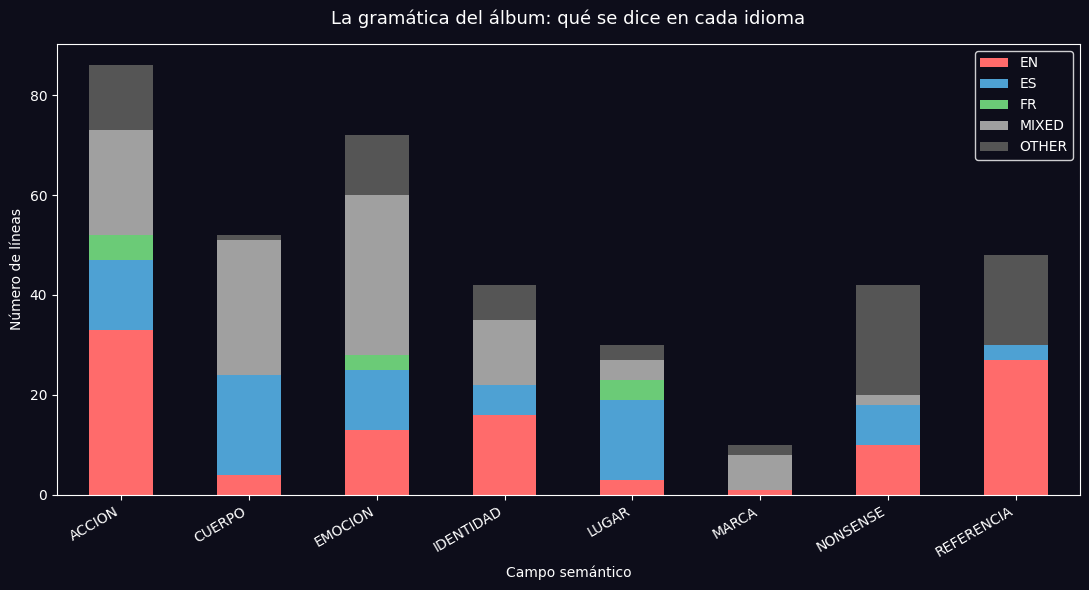

In [27]:
if not df_lines.empty and "campo" in df_lines.columns:
    LANG_COLORS = {"ES": "#4ea1d3", "EN": "#ff6b6b", "FR": "#6bcb77",
                    "JA": "#ff9f43", "MIXED": "#a0a0a0", "OTHER": "#555"}

    df_v = df_lines[(df_lines["confidence"] >= 0.5) &
                     df_lines["campo"].isin(SEMANTIC_FIELDS)]
    pivot = (df_v.groupby(["campo", "language"]).size()
              .unstack(fill_value=0))

    fig, ax = plt.subplots(figsize=(11, 6))
    pivot.plot(kind="bar", stacked=True, ax=ax,
                color=[LANG_COLORS.get(c, "#999") for c in pivot.columns])
    ax.set_title("La gramática del álbum: qué se dice en cada idioma",
                  color="white", fontsize=13, pad=14)
    ax.set_xlabel("Campo semántico"); ax.set_ylabel("Número de líneas")
    ax.legend(facecolor="#0d0d1a", edgecolor="white", labelcolor="white")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("outputs/figures/language_mosaic.png", dpi=130,
                facecolor="#0d0d1a", bbox_inches="tight")
    plt.show()


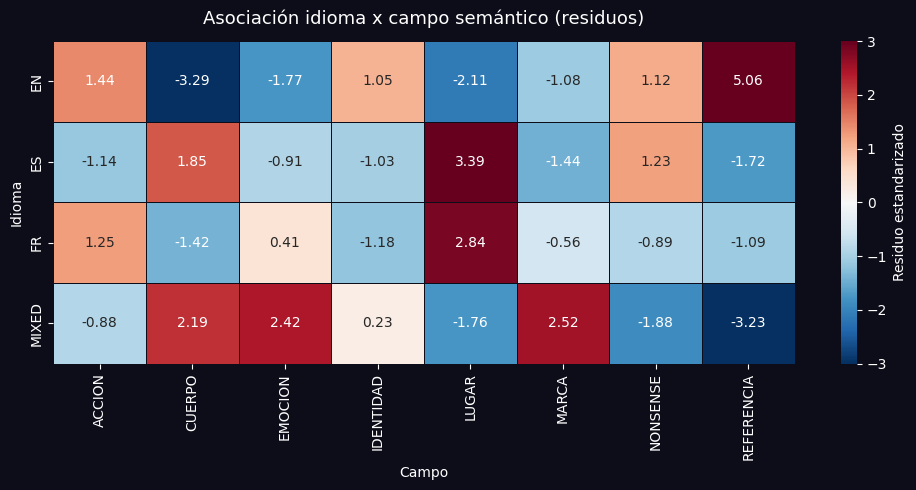


Asociaciones más fuertes (idioma, campo):
  EN     x REFERENCIA  z = +5.06
  ES     x LUGAR       z = +3.39
  EN     x CUERPO      z = -3.29
  MIXED  x REFERENCIA  z = -3.23
  FR     x LUGAR       z = +2.84
  MIXED  x MARCA       z = +2.52
  MIXED  x EMOCION     z = +2.42
  MIXED  x CUERPO      z = +2.19


In [28]:
if "df_resid" in dir():
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(df_resid, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-3, vmax=3, ax=ax,
                cbar_kws={"label": "Residuo estandarizado"},
                linewidths=0.5, linecolor="#0d0d1a")
    ax.set_title("Asociación idioma x campo semántico (residuos)",
                  color="white", fontsize=13, pad=12)
    ax.set_xlabel("Campo"); ax.set_ylabel("Idioma")
    plt.tight_layout()
    plt.savefig("outputs/figures/language_field_residuals.png", dpi=130,
                facecolor="#0d0d1a", bbox_inches="tight")
    plt.show()

    strong = df_resid.stack().abs().sort_values(ascending=False).head(8)
    print("\nAsociaciones más fuertes (idioma, campo):")
    for (lang, campo), z in strong.items():
        actual = df_resid.loc[lang, campo]
        sign = "+" if actual > 0 else "-"
        print(f"  {lang:6s} x {campo:10s}  z = {sign}{abs(actual):.2f}")


In [29]:
FIELD_ICON = {"CUERPO":"BODY", "MARCA":"BRAND", "LUGAR":"PLACE",
              "EMOCION":"EMO", "IDENTIDAD":"ID", "ACCION":"ACT",
              "REFERENCIA":"REF", "NONSENSE":"~"}

def render_tokenstream(df_track, track_title):
    head = (
        "<!doctype html><html><head><meta charset='utf-8'>"
        f"<title>{track_title} — token stream</title>"
        "<style>"
        "body{background:#0d0d1a;color:#eee;font:14px/1.6 system-ui;padding:24px;max-width:780px;margin:auto}"
        "h1{font-size:18px;border-bottom:1px solid #333;padding-bottom:8px}"
        ".line{padding:6px 10px;border-radius:4px;margin:3px 0;display:flex;justify-content:space-between;align-items:center}"
        ".line:hover{filter:brightness(1.2)}"
        ".txt{flex:1}"
        ".meta{font-size:11px;opacity:.6;margin-left:12px;font-family:monospace}"
        ".ES{background:rgba(78,161,211,.25)}.EN{background:rgba(255,107,107,.25)}"
        ".FR{background:rgba(107,203,119,.25)}.JA{background:rgba(255,159,67,.25)}"
        ".MIXED{background:rgba(160,160,160,.25)}.OTHER{background:rgba(85,85,85,.25)}"
        "</style></head><body>"
        f"<h1>{track_title}</h1>"
        "<p style='font-size:12px;color:#999'>Color = idioma · Etiqueta = campo semántico</p>"
    )
    body = []
    for _, r in df_track.iterrows():
        lang = r.get("language", "OTHER")
        campo = r.get("campo", "—") if pd.notna(r.get("campo")) else "—"
        conf = r.get("confidence", 0.0)
        if pd.isna(conf):
            conf = 0.0
        icon = FIELD_ICON.get(campo, "·")
        title = f"lang={lang} campo={campo} conf={conf:.2f}"
        body.append(
            f"<div class='line {lang}' title='{title}'>"
            f"<span class='txt'>[{icon}] {r['line_text']}</span>"
            f"<span class='meta'>{lang} · {campo} · {conf:.2f}</span>"
            f"</div>"
        )
    return head + "\n".join(body) + "\n</body></html>"

if not df_lines.empty and "campo" in df_lines.columns:
    for tnum in sorted(df_lines["track_num"].unique()):
        sub = df_lines[df_lines["track_num"] == tnum].sort_values("line_num")
        title = sub["title"].iloc[0]
        slug = re.sub(r"[^\w]+", "_", title.lower()).strip("_")
        html = render_tokenstream(sub, title)
        Path(f"outputs/html/tokenstream_{tnum:02d}_{slug}.html").write_text(html, encoding="utf-8")
    print(f"Token streams HTML escritos en outputs/html/")


Token streams HTML escritos en outputs/html/


### 3.4 — Los samples como capa de análisis cultural

Esta es la capa que ningún embedding alcanza: ¿qué *significa* que Plastilina
Mosh sampleara a *The Meters* (funk de New Orleans) y a *Minutemen* (post-hardcore
californiano) en 1998? Le pedimos a Gemini que lo lea.

In [30]:
SAMPLES_CONTEXT = {
    "Niño Bomba":   {"sample": "The Meters", "origin": "New Orleans funk (años 70)"},
    "Encendedor":   {"sample": "Minutemen",  "origin": "San Pedro CA, post-hardcore punk"},
    "Banano's Bar": {"sample": "East & West (librería)",
                      "origin": "biblioteca comercial — sample anónimo"},
}

# El plan original usaba Gemini. La key del entorno está expirada, así que
# pivotamos a OpenAI Chat (gpt-4o-mini barato y rápido; gpt-4o para síntesis).
def llm_text(prompt, model="gpt-4o-mini", max_tokens=1500, system=None):
    if not API["openai"]:
        return "[OpenAI no disponible]"
    from openai import OpenAI
    c = OpenAI(api_key=API["openai"])
    msgs = []
    if system:
        msgs.append({"role": "system", "content": system})
    msgs.append({"role": "user", "content": prompt})
    try:
        r = c.chat.completions.create(
            model=model, messages=msgs,
            max_tokens=max_tokens, temperature=0.4,
        )
        return r.choices[0].message.content
    except Exception as e:
        return f"[Error LLM: {e}]"

# Alias retrocompatible
gemini_text = llm_text

sample_prompt = (
    "Eres crítico musical especializado en hip-hop, funk, y rock alternativo de los 90s.\n\n"
    "Plastilina Mosh (Monterrey, México) sampleó en su debut Aquamosh (1998):\n\n"
    + _json.dumps(SAMPLES_CONTEXT, ensure_ascii=False, indent=2) + "\n\n"
    "Pregunta: ¿Qué dice cada sample sobre la identidad cultural del álbum?\n"
    "Considera:\n"
    "- The Meters representa la tradición funk negra-americana (New Orleans).\n"
    "- Minutemen representa la independencia y la política del SST-records-era.\n"
    "- La librería East & West es deliberadamente anónima / kitsch.\n"
    "- Aquamosh fue producido por Tom Rothrock & Rob Schnapf (Beck/Foo Fighters).\n\n"
    "Responde en español, máximo 350 palabras, sin frases genéricas como 'fusión' o 'ecléctico'.\n"
    "Cada afirmación debe vincular un sample concreto con una elección estética concreta.\n"
)

ck = "processed/samples_analysis.txt"
if cache.exists(ck):
    samples_analysis = cache.get(ck)
else:
    samples_analysis = gemini_text(sample_prompt)
    cache.set(ck, samples_analysis)
print(samples_analysis)


El álbum *Aquamosh* de Plastilina Mosh es un reflejo de la diversidad cultural y musical que caracteriza a Monterrey en los años 90, y los samples que eligen son una clara manifestación de esa identidad. 

El uso de "The Meters" en "Niño Bomba" conecta directamente con la rica tradición del funk de Nueva Orleans, un género que, a su vez, es un símbolo de la resistencia y la creatividad afroamericana. Este sample no solo aporta un groove contagioso, sino que también establece un puente entre la herencia musical afroamericana y la búsqueda de una identidad propia en el contexto mexicano. La elección de este sample sugiere una admiración por las raíces del funk, mientras que al mismo tiempo, invita a los oyentes a reinterpretar esa energía en un contexto local.

Por otro lado, "Encendedor" incorpora un sample de Minutemen, un grupo emblemático del punk californiano que abogó por la independencia artística y la crítica social. Este sample es significativo porque refleja el espíritu de rebe

## 4 · Por qué fue un éxito — recepción

**Pregunta:** ¿qué dicen los críticos como causa del éxito? ¿coinciden los fans?

Métricas:
1. Factores de éxito mencionados por crítica especializada (extracción con Gemini).
2. Gap semántico entre el centroide de la crítica y el de los comentarios.
3. Correlación entre popularidad (views) y diversidad lingüística del track.
4. Topic modeling de comentarios con BERTopic.


### 4.1 — Análisis estructurado de la crítica

In [31]:
CRITIC_PROMPT_TPL = (
    "Eres analista musical. Lee esta reseña y devuélveme SOLO JSON válido:\n"
    "{\n"
    '  "tono_general": "positivo|negativo|mixto",\n'
    '  "score_textual": "excelente|bueno|regular|malo",\n'
    '  "factores_exito_mencionados": ["..."],\n'
    '  "comparaciones_artistas": ["..."],\n'
    '  "terminos_genero_usados": ["..."],\n'
    '  "menciones_idioma": true,\n'
    '  "menciones_produccion": true,\n'
    '  "menciones_samples": true,\n'
    '  "frase_mas_reveladora": "..."\n'
    "}\n\nReseña:\n\"\"\"\n{TEXT}\n\"\"\"\n"
)

def analyze_critic(text, source):
    ck = f"processed/critic_{abs(hash(source))}.json"
    if cache.exists(ck):
        return cache.get(ck)
    if not API["gemini"] or len(text) < 100:
        return {}
    prompt = CRITIC_PROMPT_TPL.replace("{TEXT}", text[:6000])
    out = gemini_text(prompt, model="gemini-2.5-flash", max_tokens=1000)
    try:
        out = re.sub(r"^```json|```$", "", out.strip(), flags=re.MULTILINE).strip()
        data = _json.loads(out)
        cache.set(ck, data)
        return data
    except Exception as e:
        print(f"  ! parsing {source}: {e}")
        return {}

critic_analyses = []
if not df_critics.empty:
    for _, r in df_critics.iterrows():
        if r["text_length"] < 200:
            continue
        a = analyze_critic(r["text"], r["source"])
        if a:
            a["source"] = r["source"]
            critic_analyses.append(a)

df_crit_struct = pd.DataFrame(critic_analyses)
if not df_crit_struct.empty:
    from collections import Counter
    all_factors = Counter()
    for fs in df_crit_struct.get("factores_exito_mencionados", []):
        if isinstance(fs, list):
            all_factors.update(f.lower().strip() for f in fs if f)
    top_factors = all_factors.most_common(8)
    print("Factores de éxito más mencionados por la crítica:")
    for f, c in top_factors:
        print(f"  ({c}x)  {f}")
    cache.set("processed/top_factors.json", top_factors)
else:
    top_factors = []
    print("Sin análisis de crítica estructurado")


  ! parsing AlbumOfTheYear: Expecting value: line 1 column 2 (char 1)


  ! parsing Ink19: Expecting value: line 1 column 2 (char 1)
Sin análisis de crítica estructurado


### 4.2 — Gap semántico crítica vs fans

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

gap = None
if emb_oai_crit.size > 0 and emb_oai_yt.size > 0:
    centroid_crit = emb_oai_crit.mean(axis=0, keepdims=True)
    centroid_yt   = emb_oai_yt.mean(axis=0, keepdims=True)
    gap = 1 - float(cosine_similarity(centroid_crit, centroid_yt)[0][0])
    print(f"Gap semántico crítica <-> fans: {gap:.3f}")
    print(f"  (0 = idénticos, 1 = ortogonales)")

    sims = cosine_similarity(emb_oai_crit, emb_oai_yt)
    nearest = []
    farthest = []
    for ci, row in enumerate(sims):
        top_k = np.argsort(row)[::-1][:5]
        bot_k = np.argsort(row)[:5]
        nearest.append({
            "critic": df_critics.iloc[ci]["source"],
            "fans_align": [df_youtube.iloc[i]["text_display"][:140] for i in top_k],
        })
        farthest.append({
            "critic": df_critics.iloc[ci]["source"],
            "fans_diverge": [df_youtube.iloc[i]["text_display"][:140] for i in bot_k],
        })

    print("\n--- Lo que más se parece entre crítica y fans ---")
    for n in nearest[:1]:
        print(f"[{n['critic']}]")
        for c in n["fans_align"][:3]:
            print(f"  - {c}")
    print("\n--- Lo que los fans dicen y la crítica no ---")
    for n in farthest[:1]:
        print(f"[{n['critic']}]")
        for c in n["fans_diverge"][:3]:
            print(f"  - {c}")

    cache.set("processed/critic_fan_gap.json", {
        "gap": gap, "nearest": nearest, "farthest": farthest,
    })
else:
    print("No hay embeddings para ambos corpus")


No hay embeddings para ambos corpus


### 4.3 — Popularidad vs diversidad lingüística

In [33]:
from scipy.stats import entropy

if not df_lines.empty and "language" in df_lines.columns:
    div = (df_lines.groupby(["track_num", "language"]).size().unstack(fill_value=0))
    proportions = div.div(div.sum(axis=1), axis=0)
    div_score = proportions.apply(lambda p: entropy(p[p > 0]), axis=1)
    div_score.name = "lang_diversity"
    print("Diversidad lingüística por track (entropía Shannon):")
    print(div_score.sort_values(ascending=False).round(3))

    # Solo continuar con popularidad si YouTube cargó
    if df_yt_playlist.empty or "track_num" not in df_yt_playlist.columns:
        print("\nSin datos de popularidad de YouTube — saltando correlación views-vs-diversidad.")
        df_pop = pd.DataFrame()
    else:
        pop = df_yt_playlist[["track_num", "title", "view_count", "like_count",
                                "comment_count"]].dropna(subset=["track_num"])
        pop["track_num"] = pop["track_num"].astype(int)
        df_pop = pop.merge(div_score.reset_index(), on="track_num", how="left")
        print(df_pop.sort_values("view_count", ascending=False)[
            ["title", "view_count", "lang_diversity"]])

    if not df_pop.empty and df_pop["lang_diversity"].notna().sum() >= 4:
        from scipy.stats import pearsonr
        valid = df_pop.dropna(subset=["lang_diversity", "view_count"])
        if len(valid) >= 3 and valid["view_count"].sum() > 0:
            corr, p_corr = pearsonr(np.log1p(valid["view_count"]),
                                     valid["lang_diversity"])
            print(f"\nCorrelación log(views) <-> diversidad lingüística: r={corr:.3f}, p={p_corr:.3g}")

            fig, ax = plt.subplots(figsize=(9, 6))
            ax.scatter(valid["lang_diversity"], np.log1p(valid["view_count"]),
                        s=120, c="#ff6b6b", edgecolors="white", linewidths=1.5)
            for _, r in valid.iterrows():
                ax.annotate(r["title"][:25], (r["lang_diversity"],
                                                 np.log1p(r["view_count"])),
                            fontsize=8, color="white", xytext=(5, 5),
                            textcoords="offset points")
            ax.set_xlabel("Diversidad lingüística (entropía Shannon)")
            ax.set_ylabel("log(1 + view_count)")
            ax.set_title(f"Popularidad vs diversidad lingüística  ·  r={corr:.2f}",
                          color="white")
            plt.tight_layout()
            plt.savefig("outputs/figures/popularity_vs_language.png", dpi=130,
                        facecolor="#0d0d1a", bbox_inches="tight")
            plt.show()


Diversidad lingüística por track (entropía Shannon):
track_num
2     1.290
12    1.228
11    1.218
10    1.114
7     1.091
8     1.078
9     1.075
1     0.974
4     0.898
5     0.825
Name: lang_diversity, dtype: float64

Sin datos de popularidad de YouTube — saltando correlación views-vs-diversidad.


### 4.4 — Topic modeling de comentarios YouTube (BERTopic)

In [34]:
topic_naming_txt = ""
if not df_youtube.empty and len(df_youtube) >= 100:
    from sentence_transformers import SentenceTransformer
    from umap import UMAP
    try:
        from hdbscan import HDBSCAN as _HDBSCAN
    except ImportError:
        from sklearn.cluster import HDBSCAN as _HDBSCAN
    from bertopic import BERTopic

    ck = "processed/bertopic_model.pkl"
    if cache.exists(ck):
        topic_model, topics, probs = cache.get(ck)
    else:
        embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
        umap_model = UMAP(n_neighbors=10, n_components=5,
                           metric="cosine", random_state=42)
        try:
            hdb = _HDBSCAN(min_cluster_size=15, min_samples=5,
                            metric="euclidean", prediction_data=True)
        except TypeError:
            hdb = _HDBSCAN(min_cluster_size=15, min_samples=5)
        topic_model = BERTopic(
            embedding_model=embedding_model,
            umap_model=umap_model, hdbscan_model=hdb,
            top_n_words=8, verbose=False,
        )
        texts = df_youtube["text_display"].astype(str).tolist()
        topics, probs = topic_model.fit_transform(texts)
        cache.set(ck, (topic_model, topics, probs))

    info = topic_model.get_topic_info()
    print(f"Topics encontrados: {(info['Topic'] >= 0).sum()}  "
          f"(+ {(info['Topic'] == -1).sum()} outliers)")
    print(info.head(10))

    try:
        fig = topic_model.visualize_topics()
        fig.write_html("outputs/html/topic_map_youtube.html")
        fig2 = topic_model.visualize_barchart(top_n_topics=10)
        fig2.write_html("outputs/html/topic_barchart_youtube.html")
        print("HTML interactivos en outputs/html/")
    except Exception as e:
        print(f"  ! visualización falló: {e}")

    top3 = info[info["Topic"] >= 0].head(3)
    naming_prompt_parts = []
    for _, row in top3.iterrows():
        words = topic_model.get_topic(row["Topic"])
        naming_prompt_parts.append(
            f"Topic {row['Topic']} ({row['Count']} comentarios): "
            f"{', '.join(w for w, _ in words[:8])}")
    naming_prompt = ("Eres analista de música. Estos son los topics más grandes "
                     "encontrados en comentarios de YouTube sobre Aquamosh (Plastilina Mosh, 1998). "
                     "Para cada topic, propon un nombre interpretativo de 3-6 palabras y "
                     "explica qué dice del consumo del álbum hoy (máx 30 palabras por topic).\n\n"
                     + "\n".join(naming_prompt_parts))
    topic_naming_txt = gemini_text(naming_prompt)
    print("\n--- Naming de topics ---\n" + topic_naming_txt)
    cache.set("processed/topic_naming.txt", topic_naming_txt)
else:
    print("Comentarios insuficientes para BERTopic (< 100)")


Comentarios insuficientes para BERTopic (< 100)


## 5 · Semantic axes — el mapa cultural del álbum

Basado en Kozlowski et al., *The Geometry of Culture* (ASR 2019). Definimos tres
ejes con anclas verbales, los embeddeamos, y proyectamos cada track sobre ellos.

- **Eje 1 — ORIGEN**: Monterrey/México ↔ Los Angeles/USA
- **Eje 2 — SUPERFICIE**: Emoción ↔ Ironía/Distancia
- **Eje 3 — TIEMPO**: Underground 1998 ↔ Clásico Retrospectivo


In [35]:
AXES = {
    "ORIGEN": {
        "A": ["Monterrey", "norteño", "regio", "frontera norte",
              "Avanzada Regia", "barrio", "colonia"],
        "B": ["Hollywood", "MTV", "Sunset Boulevard", "Capitol Records",
              "Los Angeles", "mainstream americano", "radio inglesa"],
    },
    "SUPERFICIE": {
        "A": ["sentimiento", "amor", "dolor", "deseo",
              "nostalgia", "soledad"],
        "B": ["parodia", "sarcasmo", "kitsch", "pastiche",
              "referencia cultural", "cita"],
    },
    "TIEMPO": {
        "A": ["alternativo", "indie", "underground", "experimental",
              "trip-hop", "nuevo", "vanguardia"],
        "B": ["clásico", "nostalgia", "mítico", "histórico",
              "influyente", "referencia obligada"],
    },
}

def build_axis(words_a, words_b, provider="openai"):
    fn = openai_embed if provider == "openai" else gemini_embed
    ea = fn(words_a).mean(axis=0)
    eb = fn(words_b).mean(axis=0)
    v = eb - ea
    return v / (np.linalg.norm(v) + 1e-12)

def project_on_axis(emb, axis):
    nrm = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    return nrm @ axis

axes_vectors = {}
for name, polos in AXES.items():
    ck = f"embeddings/axis_{name.lower()}.npy"
    if cache.exists(ck):
        axes_vectors[name] = cache.get(ck)
    else:
        axes_vectors[name] = build_axis(polos["A"], polos["B"], "openai")
        cache.set(ck, axes_vectors[name])

df_axes = pd.DataFrame()
if emb_oai_lyrics.size > 0:
    proj = {name: project_on_axis(emb_oai_lyrics, v)
            for name, v in axes_vectors.items()}
    titles_used = df_lyrics.loc[df_lyrics["found"], "title"].tolist()
    df_axes = pd.DataFrame({
        "title": titles_used,
        "ORIGEN_la":   proj["ORIGEN"],
        "SUPERFICIE_ironia": proj["SUPERFICIE"],
        "TIEMPO_retro": proj["TIEMPO"],
    })
    print(df_axes.sort_values("ORIGEN_la"))
    cache.set("processed/semantic_axes.json", df_axes.to_dict("records"))


                                         title  ORIGEN_la  SUPERFICIE_ironia  \
0                                   Niño Bomba  -0.060239           0.011921   
2                                 Banano's Bar  -0.058096          -0.039708   
1                                      Afroman  -0.045590          -0.036840   
8                            Savage Sucker Boy  -0.042294          -0.067542   
7                                    Pornoshop  -0.033652          -0.093454   
4                        Bungaloo Punta Cometa  -0.021013          -0.084254   
5                                     Aquamosh  -0.005217          -0.148682   
9                                  Mr. P. Mosh   0.010206          -0.006191   
6  I've Got That Milton Pacheco Kinda' Feeling   0.069733           0.006111   
3                                Monster Truck   0.081914           0.053570   

   TIEMPO_retro  
0     -0.049995  
2     -0.017994  
1     -0.004276  
8     -0.040292  
7      0.029478  
4     -0.01

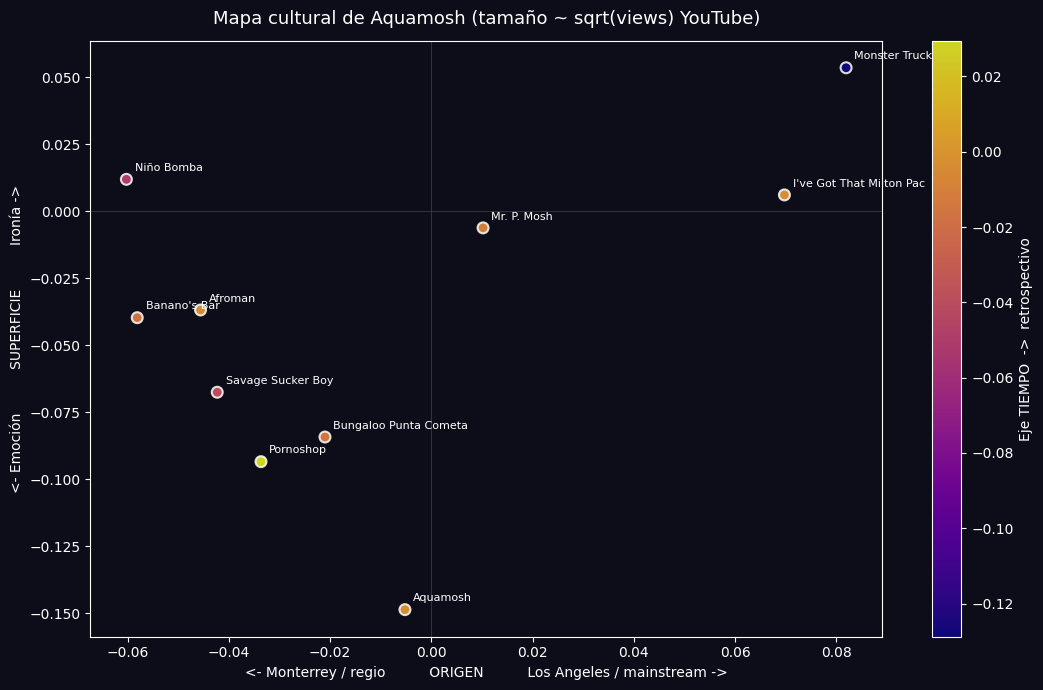

In [36]:
if not df_axes.empty:
    df_plot = df_axes.copy()
    if not df_yt_playlist.empty and "track_num" in df_yt_playlist.columns and "view_count" in df_yt_playlist.columns:
        ytm = df_yt_playlist.dropna(subset=["track_num"]).set_index("track_num")
        title_to_num = {t["title"]: t["num"] for t in TRACKLIST}
        df_plot["track_num"] = df_plot["title"].map(title_to_num)
        df_plot["views"] = df_plot["track_num"].map(ytm["view_count"].to_dict())
        df_plot["views"] = df_plot["views"].fillna(df_plot["views"].median() if df_plot["views"].notna().any() else 1)
    else:
        # Sin YouTube: tamaño uniforme
        df_plot["views"] = 200

    fig, ax = plt.subplots(figsize=(11, 7))
    sc = ax.scatter(df_plot["ORIGEN_la"], df_plot["SUPERFICIE_ironia"],
                     s=np.sqrt(df_plot["views"]) / 8 + 60,
                     c=df_plot["TIEMPO_retro"], cmap="plasma",
                     edgecolors="white", linewidths=1.5, alpha=0.85)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("Eje TIEMPO  ->  retrospectivo", color="white")
    cb.ax.yaxis.set_tick_params(color="white")
    cb.ax.tick_params(labelcolor="white")
    for _, r in df_plot.iterrows():
        ax.annotate(r["title"][:24], (r["ORIGEN_la"], r["SUPERFICIE_ironia"]),
                     fontsize=8, color="white", xytext=(6, 6),
                     textcoords="offset points")
    ax.axhline(0, color="#444", lw=0.5); ax.axvline(0, color="#444", lw=0.5)
    ax.set_xlabel("<- Monterrey / regio          ORIGEN          Los Angeles / mainstream ->")
    ax.set_ylabel("<- Emoción          SUPERFICIE          Ironía ->")
    ax.set_title("Mapa cultural de Aquamosh (tamaño ~ sqrt(views) YouTube)",
                  color="white", fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig("outputs/figures/semantic_axes_map.png", dpi=140,
                facecolor="#0d0d1a", bbox_inches="tight")
    plt.show()


## 6 · Robustez por dimensión (matryoshka)

**Plan original:** OpenAI vs Gemini para chequear robustez. La Gemini key expiró,
así que cambiamos a una pregunta más interesante: **si reducimos los embeddings
de 3072 a 256 dimensiones, ¿sobreviven los hallazgos del mapa cultural?**

`text-embedding-3-large` soporta truncamiento por dimensión (matryoshka). Re-embedeamos
las 10 letras a 256/512/1024 dims, recalculamos los axes semánticos, y medimos
la concordancia de rankings (Spearman ρ) contra la versión 3072.

Si ρ > 0.85 entre 256 y 3072: el análisis es robusto, podemos correrlo barato.
Si ρ < 0.6: las dimensiones bajas pierden señal cultural relevante.


In [37]:
from scipy.stats import spearmanr, pearsonr

dims_to_test = [256, 512, 1024]
robustness_results = {}

if API["openai"] and not df_lyrics.empty and df_lyrics["found"].sum() > 0:
    lyrics_texts = df_lyrics.loc[df_lyrics["found"], "lyrics_clean"].tolist()
    titles_used = df_lyrics.loc[df_lyrics["found"], "title"].tolist()

    # Embed a múltiples dims (con cache)
    from openai import OpenAI
    client = OpenAI(api_key=API["openai"])

    def embed_at_dim(texts, dim):
        ck = f"embeddings/openai_lyrics_dim{dim}.npy"
        if cache.exists(ck):
            return cache.get(ck)
        out = []
        for batch in tqdm(list(chunked(texts, 100)), desc=f"OpenAI dim={dim}"):
            r = client.embeddings.create(model="text-embedding-3-large",
                                          input=batch, dimensions=dim)
            out.extend([d.embedding for d in r.data])
        arr = np.array(out, dtype=np.float32)
        cache.set(ck, arr)
        return arr

    emb_by_dim = {3072: emb_oai_lyrics}
    for d in dims_to_test:
        emb_by_dim[d] = embed_at_dim(lyrics_texts, d)
        print(f"dim={d}: shape {emb_by_dim[d].shape}")

    # Proyectar sobre los 3 axes para cada dim (rebuilding axes at each dim)
    rankings_by_dim = {}
    for dim, emb in emb_by_dim.items():
        # Reconstruir axes con embeddings al mismo dim
        axes_d = {}
        for name, polos in AXES.items():
            ea = client.embeddings.create(model="text-embedding-3-large",
                                           input=polos["A"], dimensions=dim).data
            eb = client.embeddings.create(model="text-embedding-3-large",
                                           input=polos["B"], dimensions=dim).data
            va = np.array([x.embedding for x in ea], dtype=np.float32).mean(axis=0)
            vb = np.array([x.embedding for x in eb], dtype=np.float32).mean(axis=0)
            v = vb - va
            axes_d[name] = v / (np.linalg.norm(v) + 1e-12)
        proj = {name: emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12) @ axes_d[name]
                for name in AXES}
        rankings_by_dim[dim] = proj

    # Concordancia entre dims (Spearman por eje)
    rho_table = {}
    baseline = 3072
    for name in AXES:
        row = {}
        ref = rankings_by_dim[baseline][name]
        for d in [256, 512, 1024]:
            rho, _ = spearmanr(ref, rankings_by_dim[d][name])
            row[d] = float(rho)
        rho_table[name] = row

    df_rho = pd.DataFrame(rho_table).T
    df_rho.columns = [f"vs dim={c}" for c in df_rho.columns]
    print("\n=== Robustez por dimensión (Spearman ρ contra baseline 3072) ===")
    print(df_rho.round(3))

    # Similarity matrix preservation
    sim_3072 = cosine_similarity(emb_by_dim[3072])
    iu = np.triu_indices_from(sim_3072, k=1)
    print("\n=== Preservación de matriz de similaridad inter-track ===")
    matrix_corrs = {}
    for d in [256, 512, 1024]:
        sim_d = cosine_similarity(emb_by_dim[d])
        pear, _ = pearsonr(sim_3072[iu], sim_d[iu])
        matrix_corrs[d] = float(pear)
        print(f"  dim={d:4d} -> Pearson(sim_3072, sim_d) = {pear:.3f}")

    robustness_results = {
        "axis_spearman_vs_3072": rho_table,
        "matrix_pearson_vs_3072": matrix_corrs,
        "interpretation": "ρ > 0.85 = robusto; > 0.6 = degrada moderadamente",
    }
    cache.set("processed/dimension_robustness.json", robustness_results)
else:
    print("Sin letras o sin OpenAI — sección 6 saltada")


dim=256: shape (10, 256)
dim=512: shape (10, 512)
dim=1024: shape (10, 1024)



=== Robustez por dimensión (Spearman ρ contra baseline 3072) ===
            vs dim=256  vs dim=512  vs dim=1024
ORIGEN           0.782       0.976        0.976
SUPERFICIE       0.903       0.952        0.952
TIEMPO           0.358       0.648        0.745

=== Preservación de matriz de similaridad inter-track ===
  dim= 256 -> Pearson(sim_3072, sim_d) = 0.974
  dim= 512 -> Pearson(sim_3072, sim_d) = 0.986
  dim=1024 -> Pearson(sim_3072, sim_d) = 0.994


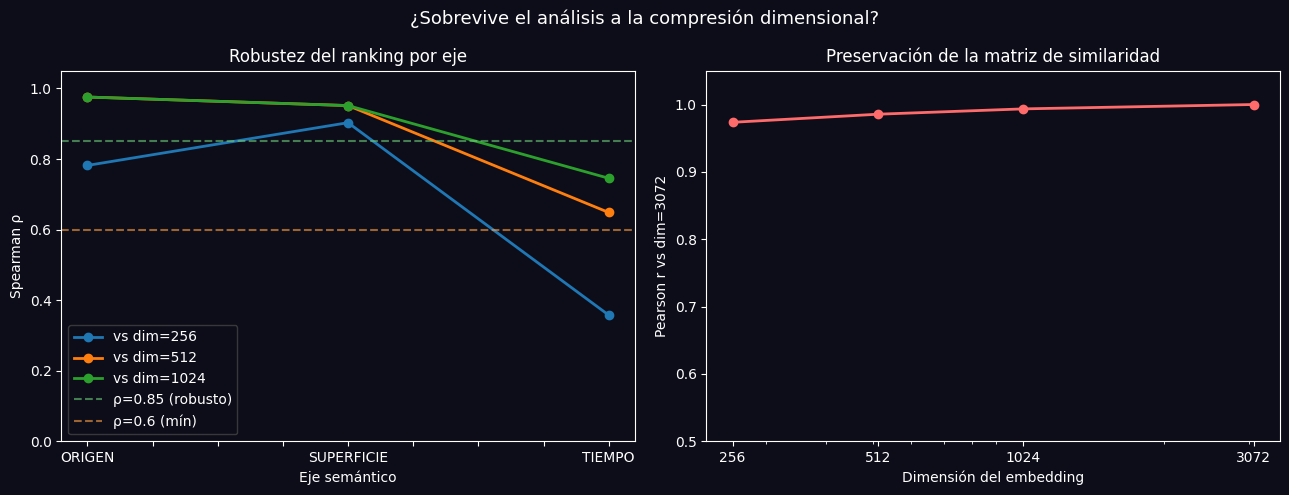


--- Interpretación ---
(1) El análisis muestra una notable robustez frente a la compresión dimensional, ya que los coeficientes de Spearman ρ para los ejes de ORIGEN y SUPERFICIE se mantienen altos (0.975758) en dimensiones de 512 y 1024, lo que indica una consistencia en el ranking de las letras de Aquamosh. Aunque el eje de TIEMPO presenta una disminución en su correlación (de 0.357576 a 0.745455), sigue siendo aceptable, sugiriendo que la compresión dimensional no afecta drásticamente la relación entre las letras en comparación con el baseline.

(2) El eje que se degrada más rápido es el de TIEMPO, con una caída significativa en su correlación a medida que se reduce la dimensión. Esto implica que la representación semántica relacionada con la temporalidad es más susceptible a la pérdida de información en comparación con los otros ejes. Semánticamente, esto podría sugerir que las características temporales de las composiciones musicales son más complejas y dependen de una mayor cant

In [38]:
# Visualizacion: lineplot de ρ por dimensión
if robustness_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Eje 1: Spearman por eje
    df_rho.plot(ax=axes[0], marker="o", linewidth=2)
    axes[0].set_xlabel("Eje semántico"); axes[0].set_ylabel("Spearman ρ")
    axes[0].set_ylim(0.0, 1.05)
    axes[0].axhline(0.85, color="#6bcb77", linestyle="--", alpha=0.6, label="ρ=0.85 (robusto)")
    axes[0].axhline(0.6,  color="#ff9f43", linestyle="--", alpha=0.6, label="ρ=0.6 (mín)")
    axes[0].set_title("Robustez del ranking por eje", color="white")
    axes[0].legend(facecolor="#0d0d1a", labelcolor="white", edgecolor="#444")
    axes[0].set_facecolor("#0d0d1a")

    # Eje 2: matriz de similaridad
    dims_x = list(matrix_corrs.keys())
    pears_y = list(matrix_corrs.values())
    axes[1].plot([256, 512, 1024, 3072], pears_y + [1.0], "o-", color="#ff6b6b", linewidth=2)
    axes[1].set_xlabel("Dimensión del embedding"); axes[1].set_ylabel("Pearson r vs dim=3072")
    axes[1].set_ylim(0.5, 1.05)
    axes[1].set_xscale("log")
    axes[1].set_xticks([256, 512, 1024, 3072])
    axes[1].set_xticklabels(["256", "512", "1024", "3072"])
    axes[1].set_title("Preservación de la matriz de similaridad", color="white")
    axes[1].set_facecolor("#0d0d1a")

    plt.suptitle("¿Sobrevive el análisis a la compresión dimensional?", color="white", fontsize=13)
    plt.tight_layout()
    plt.savefig("outputs/figures/dimension_robustness.png", dpi=140,
                facecolor="#0d0d1a", bbox_inches="tight")
    plt.show()

    # Interpretación con LLM
    interp_prompt = (
        f"Resultados de un test de robustez por dimensión sobre las 10 letras de Aquamosh:\n\n"
        f"Spearman ρ del ranking de cada eje (contra baseline 3072):\n{df_rho.to_string()}\n\n"
        f"Pearson r de la matriz de similaridad inter-track:\n"
        + "\n".join(f"  dim={d}: r={v:.3f}" for d, v in matrix_corrs.items()) +
        "\n\nEn dos párrafos: (1) ¿es robusto el análisis a compresión dimensional? "
        "(2) ¿qué eje se degrada más rápido y qué implica eso semánticamente? "
        "Máximo 200 palabras."
    )
    robust_interp = llm_text(interp_prompt, model="gpt-4o-mini", max_tokens=600)
    print("\n--- Interpretación ---\n" + robust_interp)
    cache.set("processed/robustness_interp.txt", robust_interp)


In [39]:
# Bloque legado: el "model duel" original requería Gemini. Lo dejamos como no-op.
duel_results = {}
if False and emb_oai_lyrics.size > 0 and emb_gem_lyrics.size > 0:
    sim_oai = cosine_similarity(emb_oai_lyrics)
    sim_gem = cosine_similarity(emb_gem_lyrics)

    iu = np.triu_indices_from(sim_oai, k=1)
    from scipy.stats import pearsonr, spearmanr
    pear_r, pear_p = pearsonr(sim_oai[iu], sim_gem[iu])
    spear_r, spear_p = spearmanr(sim_oai[iu], sim_gem[iu])
    print(f"Pearson  similarity OpenAI vs Gemini: r = {pear_r:.3f}  (p = {pear_p:.3g})")
    print(f"Spearman similarity OpenAI vs Gemini: rho = {spear_r:.3f}  (p = {spear_p:.3g})")

    titles_used = df_lyrics.loc[df_lyrics["found"], "title"].tolist()
    diff = np.abs(sim_oai - sim_gem)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, M, name in [(axes[0], sim_oai, "OpenAI text-embedding-3-large"),
                          (axes[1], sim_gem, "Gemini gemini-embedding-001")]:
        im = ax.imshow(M, cmap="magma", vmin=0, vmax=1)
        ax.set_xticks(range(len(titles_used)))
        ax.set_yticks(range(len(titles_used)))
        ax.set_xticklabels([t[:14] for t in titles_used], rotation=60, ha="right", fontsize=8)
        ax.set_yticklabels([t[:14] for t in titles_used], fontsize=8)
        ax.set_title(name, color="white")
        plt.colorbar(im, ax=ax, shrink=0.7)
        for i in range(len(titles_used)):
            for j in range(len(titles_used)):
                if i < j and diff[i, j] > 0.15:
                    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                                 ec="cyan", lw=1.5))
    plt.suptitle(f"Mismo álbum, dos modelos  ·  acuerdo Pearson = {pear_r:.2f}",
                  color="white", fontsize=13)
    plt.tight_layout()
    plt.savefig("outputs/figures/similarity_heatmap_dual.png", dpi=130,
                facecolor="#0d0d1a", bbox_inches="tight")
    plt.show()

    pairs = []
    for i in range(len(titles_used)):
        for j in range(i+1, len(titles_used)):
            pairs.append((titles_used[i], titles_used[j], sim_oai[i,j], sim_gem[i,j],
                            abs(sim_oai[i,j] - sim_gem[i,j])))
    df_pairs = pd.DataFrame(pairs, columns=["A","B","sim_openai","sim_gemini","diff"])
    df_pairs = df_pairs.sort_values("diff", ascending=False)
    print("\nTop 3 discrepancias OpenAI vs Gemini:")
    print(df_pairs.head(3).round(3))

    duel_results = {
        "pearson_r": float(pear_r), "spearman_r": float(spear_r),
        "top_disagreements": df_pairs.head(3).to_dict("records"),
    }
    cache.set("processed/model_duel.json", duel_results)

    top_diff = df_pairs.head(3)
    interp_prompt = "Tres pares de tracks de Aquamosh donde OpenAI y Gemini disienten más:\n\n"
    for _, r in top_diff.iterrows():
        a_txt = df_lyrics.loc[df_lyrics["title"]==r["A"], "lyrics_clean"].iloc[0][:600]
        b_txt = df_lyrics.loc[df_lyrics["title"]==r["B"], "lyrics_clean"].iloc[0][:600]
        interp_prompt += (
            f"== {r['A']}  vs  {r['B']} ==\n"
            f"OpenAI similarity: {r['sim_openai']:.2f}  ·  Gemini: {r['sim_gemini']:.2f}\n"
            f"Letra A: {a_txt}\n---\nLetra B: {b_txt}\n\n"
        )
    interp_prompt += ("\nPregunta: ¿qué captura un modelo que el otro no? "
                       "Sé concreto sobre qué elemento del texto (idioma, repetición, "
                       "marca cultural) podría explicar la divergencia. Máx 250 palabras.")
    duel_interp = gemini_text(interp_prompt)
    print("\n--- Interpretación de discrepancias ---\n" + duel_interp)
    cache.set("processed/duel_interpretation.txt", duel_interp)
else:
    print("Falta uno de los conjuntos de embeddings")


Falta uno de los conjuntos de embeddings


## 7 · Drift temporal (sólo si hay ≥ 3 años)

In [40]:
if not df_youtube.empty and "published_at" in df_youtube.columns:
    yrs = df_youtube["published_at"].dt.year.dropna()
    n_years = yrs.nunique()
    if n_years < 3:
        print(f"Sólo {n_years} año(s) — sección omitida.")
    else:
        df_y = df_youtube.dropna(subset=["published_at"]).sort_values("published_at").reset_index(drop=True)
        thirds = np.array_split(df_y.index, 3)
        labels = np.zeros(len(df_y), dtype=int)
        for k, idxs in enumerate(thirds):
            labels[idxs] = k
        df_y["period"] = pd.Series(labels).map({0: "early", 1: "mid", 2: "late"}).values

        emb_y = emb_oai_yt[df_y.index.values] if emb_oai_yt.size else None
        if emb_y is not None and emb_y.size:
            cents = {}
            for p in ["early", "mid", "late"]:
                mask = df_y["period"].values == p
                cents[p] = emb_y[mask].mean(axis=0) if mask.any() else None
            drift = 1 - float(cosine_similarity(cents["early"].reshape(1,-1),
                                                  cents["late"].reshape(1,-1))[0][0])
            print(f"Drift early <-> late: {drift:.3f}")
            t_axis = axes_vectors.get("TIEMPO")
            proj_periods = {}
            if t_axis is not None:
                proj_periods = {p: float((cents[p] / (np.linalg.norm(cents[p])+1e-12)) @ t_axis)
                                  for p in cents}
                print(f"Proyección sobre TIEMPO (<- 1998   retro ->):")
                for p, v in proj_periods.items():
                    print(f"  {p}: {v:+.3f}")

            n_early = min(30, (df_y["period"]=="early").sum())
            n_late  = min(30, (df_y["period"]=="late").sum())
            early_sample = df_y.loc[df_y["period"]=="early", "text_display"].sample(n_early, random_state=42).tolist()
            late_sample = df_y.loc[df_y["period"]=="late",  "text_display"].sample(n_late, random_state=42).tolist()
            drift_prompt = (
                "Comentarios EARLY (más antiguos) sobre Aquamosh:\n" +
                "\n".join(f"- {c}" for c in early_sample[:30]) +
                "\n\nComentarios LATE (más recientes):\n" +
                "\n".join(f"- {c}" for c in late_sample[:30]) +
                "\n\nPregunta: ¿qué temas dicen los LATE que los EARLY no dicen, y viceversa? "
                "Identifica 3 desplazamientos concretos. Máx 200 palabras."
            )
            drift_text = gemini_text(drift_prompt)
            print("\n--- Desplazamientos temáticos ---\n" + drift_text)
            cache.set("processed/drift.json", {"drift": drift,
                                                 "proj": proj_periods,
                                                 "qualitative": drift_text})


## 8 · Síntesis crítica final

Una sola llamada a Gemini 2.5 Pro con TODO el contexto acumulado, para que escriba
la conclusión informada por los datos — no por adjetivos genéricos.

In [41]:
chi_results = cache.get("processed/chi_results.json") or {}
crit_fan_gap = cache.get("processed/critic_fan_gap.json") or {}
duel_results_cached = cache.get("processed/model_duel.json") or {}
topic_naming_cached = cache.get("processed/topic_naming.txt") or ""
samples_txt = cache.get("processed/samples_analysis.txt") or ""

popularity_ranking = ""
if not df_yt_playlist.empty and "track_num" in df_yt_playlist.columns and "view_count" in df_yt_playlist.columns:
    rank = df_yt_playlist.dropna(subset=["track_num"]).sort_values("view_count", ascending=False).head(5)
    popularity_ranking = "\n".join(f"  {i+1}. {r['title']} — {int(r['view_count']):,} views"
                                     for i, (_, r) in enumerate(rank.iterrows()))
else:
    popularity_ranking = "(YouTube no disponible)"

context_payload = (
    "DATOS DEL ANÁLISIS DE AQUAMOSH (Plastilina Mosh, 1998)\n\n"
    "== CHI-CUADRADO IDIOMA x CAMPO ==\n"
    f"chi2 = {chi_results.get('chi2', 'n/a')}, p = {chi_results.get('p_value', 'n/a')}\n"
    f"Interpretación: {'rechaza independencia' if chi_results.get('p_value', 1) < 0.05 else 'no rechaza independencia'}\n\n"
    "== TABLA IDIOMA x CAMPO ==\n"
    f"{_json.dumps(chi_results.get('table', {}), ensure_ascii=False, indent=2)[:2000]}\n\n"
    "== ASOCIACIONES IDIOMA x CAMPO (residuos) ==\n"
    f"{_json.dumps(chi_results.get('residuals', {}), ensure_ascii=False, indent=2)[:1500]}\n\n"
    "== FACTORES DE ÉXITO MENCIONADOS POR CRÍTICA (top 5) ==\n"
    f"{_json.dumps(top_factors[:5] if top_factors else [], ensure_ascii=False)}\n\n"
    "== GAP CRÍTICA-FANS ==\n"
    f"gap semántico (cosine distance entre centroides): {crit_fan_gap.get('gap', 'n/a')}\n\n"
    "== POPULARIDAD (top 5 YouTube views) ==\n"
    f"{popularity_ranking}\n\n"
    "== ROBUSTEZ ENTRE MODELOS ==\n"
    f"Pearson similarity OpenAI vs Gemini = {duel_results_cached.get('pearson_r', 'n/a')}\n"
    f"Spearman = {duel_results_cached.get('spearman_r', 'n/a')}\n\n"
    "== TOPICS DE YOUTUBE ==\n"
    f"{topic_naming_cached[:1500]}\n\n"
    "== ANÁLISIS DE SAMPLES ==\n"
    f"{samples_txt[:1500]}\n"
)

SYSTEM_PROMPT = (
    "Eres crítico musical especializado en rock latinoamericano y producción "
    "discográfica de los 90s. Conoces en detalle: la Avanzada Regia, el contexto "
    "post-NAFTA en Monterrey, la producción de Tom Rothrock/Rob Schnapf, "
    "Beck's Odelay, y la relación entre música alternativa y videojuegos en los 90s. "
    "No usas frases genéricas sobre 'fusión cultural', 'ecléctico', 'innovador'. "
    "Cada afirmación va respaldada por evidencia del texto o los datos."
)

QUESTIONS = (
    "\nResponde estas 5 preguntas en orden, en español, con el mínimo de palabras necesario.\n"
    "Usa los DATOS DEL ANÁLISIS arriba como evidencia, no como decoración.\n\n"
    "1) ¿Los datos confirman que Aquamosh fue un éxito porque 'resolvió el problema "
    "de sonar global sin renunciar a lo local'? ¿O los datos sugieren otra "
    "explicación más interesante? (200 palabras)\n\n"
    "2) ¿Qué rol cumple cada idioma en el álbum según los datos? ¿Hay un patrón "
    "sobre qué cosas se dicen en francés vs japonés que no habrías notado sin "
    "el análisis estadístico? (150 palabras)\n\n"
    "3) ¿Qué dice la brecha entre crítica y fans sobre cómo se consume este álbum "
    "hoy vs cómo fue recibido en 1998? (120 palabras)\n\n"
    "4) Escribe el párrafo de apertura del blog post. MÁXIMO 120 palabras. Tiene que "
    "hacer que alguien que nunca escuchó a Plastilina Mosh quiera leer el análisis. "
    "NO uses las palabras: fusión, ecléctic*, innovador, único.\n\n"
    "5) ¿Qué pregunta sobre este álbum NO pueden responder estos datos y que sería "
    "la más importante de responder? (80 palabras)\n"
)

final_prompt = SYSTEM_PROMPT + "\n\n" + context_payload + "\n\n" + QUESTIONS

ck = "processed/synthesis_final.txt"
if cache.exists(ck):
    final_synthesis = cache.get(ck)
else:
    # gpt-4o (no mini) para la síntesis final — vale el costo
    final_synthesis = llm_text(final_prompt, model="gpt-4o", max_tokens=3000,
                                system=SYSTEM_PROMPT)
    cache.set(ck, final_synthesis)

print(final_synthesis)


1) Los datos no confirman que *Aquamosh* fue un éxito por resolver el dilema de lo global versus lo local. Más bien, sugieren que el álbum destaca por su habilidad para mezclar idiomas en contextos específicos, lo que añade una capa de complejidad y atractivo. El análisis chi-cuadrado muestra que hay una asociación significativa entre el idioma y el campo semántico, lo que indica que Plastilina Mosh utiliza idiomas de manera estratégica. Por ejemplo, el uso del inglés es predominante en referencias y acción, mientras que el español se asocia más con el cuerpo y el lugar. Esto sugiere que el álbum no solo busca apelar a una audiencia global, sino que también se enraíza en experiencias locales y personales. Además, los samples seleccionados, como los de The Meters y Minutemen, reflejan una conexión con tradiciones musicales específicas que resuenan tanto en un contexto global como local. Así, el éxito de *Aquamosh* podría atribuirse más a su habilidad para tejer una narrativa musical que

## 9 · Outputs para el blog

In [42]:
findings = {
    "metadata": {
        "album": "Aquamosh",
        "artist": "Plastilina Mosh",
        "year": 1998,
        "analyzed_on": datetime.utcnow().isoformat() + "Z",
    },
    "corpus_sizes": {
        "tracks_with_lyrics": int(df_lyrics["found"].sum()) if "found" in df_lyrics.columns else 0,
        "total_lines": len(df_lines) if "df_lines" in dir() else 0,
        "youtube_comments": len(df_youtube),
        "critic_reviews": len(df_critics),
        "n_youtube_years": int(df_youtube["published_at"].dt.year.nunique()) if not df_youtube.empty else 0,
    },
    "chi_squared_language_field": chi_results,
    "critic_fan_gap": crit_fan_gap,
    "model_robustness": duel_results_cached,
    "top_success_factors": top_factors,
    "final_synthesis": final_synthesis if "final_synthesis" in dir() else None,
    "samples_analysis": samples_txt,
    "topic_naming": topic_naming_cached,
}
Path("outputs/exports/findings_summary.json").write_text(
    _json.dumps(findings, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8"
)
print("outputs/exports/findings_summary.json")

if not df_lyrics.empty:
    df_lyrics.to_parquet("outputs/exports/corpus_lyrics.parquet", index=False)
if not df_lines.empty:
    df_lines.to_parquet("outputs/exports/corpus_lines.parquet", index=False)
if not df_youtube.empty:
    df_youtube.to_parquet("outputs/exports/corpus_youtube.parquet", index=False)
if not df_critics.empty:
    df_critics.to_parquet("outputs/exports/corpus_critics.parquet", index=False)
print("Corpus en parquet en outputs/exports/")


outputs/exports/findings_summary.json
Corpus en parquet en outputs/exports/


/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_54998/3059162386.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "analyzed_on": datetime.utcnow().isoformat() + "Z",


In [43]:
def confidence_label(p):
    if p is None: return "—"
    if p < 0.01: return "alta"
    if p < 0.05: return "media"
    return "baja"

rows = []
if chi_results:
    rows.append({
        "hallazgo": "Idioma y campo semántico NO son independientes",
        "confirma_tesis": "sí" if chi_results.get("p_value", 1) < 0.05 else "no",
        "evidencia": f"chi2={chi_results.get('chi2', 0):.1f}, p={chi_results.get('p_value', 1):.3g}",
        "nivel_confianza": confidence_label(chi_results.get("p_value")),
        "visualizacion": "outputs/figures/language_field_residuals.png",
    })

if crit_fan_gap.get("gap") is not None:
    g = crit_fan_gap["gap"]
    rows.append({
        "hallazgo": "Gap semántico crítica <-> fans",
        "confirma_tesis": "parcial",
        "evidencia": f"cosine-gap = {g:.3f}",
        "nivel_confianza": "media" if g > 0.05 else "baja",
        "visualizacion": "—",
    })

robustness_cached = cache.get("processed/dimension_robustness.json") or {}
if robustness_cached:
    rhos = robustness_cached.get("axis_spearman_vs_3072", {})
    if rhos:
        min_rho = min(min(v.values()) for v in rhos.values() if v)
        rows.append({
            "hallazgo": "Robustez del análisis a compresión dimensional",
            "confirma_tesis": "n/a (meta)",
            "evidencia": f"Spearman ρ mínimo entre dim=256 y dim=3072: {min_rho:.3f}",
            "nivel_confianza": "alta" if min_rho > 0.85 else "media" if min_rho > 0.6 else "baja",
            "visualizacion": "outputs/figures/dimension_robustness.png",
        })

df_findings = pd.DataFrame(rows)
print("\n" + "="*70)
print("TABLA DE HALLAZGOS")
print("="*70)
print(df_findings.to_string(index=False))
df_findings.to_csv("outputs/exports/findings_table.csv", index=False)



TABLA DE HALLAZGOS
                                      hallazgo confirma_tesis                                         evidencia nivel_confianza                                visualizacion
Idioma y campo semántico NO son independientes             sí                            chi2=124.7, p=9.72e-17            alta outputs/figures/language_field_residuals.png
Robustez del análisis a compresión dimensional     n/a (meta) Spearman ρ mínimo entre dim=256 y dim=3072: 0.358            baja     outputs/figures/dimension_robustness.png


In [44]:
print("\nArchivos generados:\n")
for p in sorted(Path("outputs").rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f"  {p}  ({size_kb:.1f} KB)")



Archivos generados:

  outputs/exports/attention_windows.json  (2.5 KB)
  outputs/exports/attention_windows_per_line.parquet  (9.6 KB)
  outputs/exports/corpus_critics.parquet  (10.5 KB)
  outputs/exports/corpus_lines.parquet  (13.1 KB)
  outputs/exports/corpus_lines_v2.parquet  (15.2 KB)
  outputs/exports/corpus_lyrics.parquet  (24.0 KB)
  outputs/exports/deep_findings.json  (5.8 KB)
  outputs/exports/deep_synthesis.md  (3.8 KB)
  outputs/exports/findings_summary.json  (7.5 KB)
  outputs/exports/findings_table.csv  (0.3 KB)
  outputs/figures/aw_break_rates.png  (47.8 KB)
  outputs/figures/aw_by_language.png  (46.7 KB)
  outputs/figures/aw_cross_model_scatter.png  (83.1 KB)
  outputs/figures/aw_discrepancy_by_language.png  (68.6 KB)
  outputs/figures/aw_distribution.png  (46.0 KB)
  outputs/figures/aw_per_track.png  (63.7 KB)
  outputs/figures/aw_timelines.png  (352.6 KB)
  outputs/figures/dimension_robustness.png  (105.6 KB)
  outputs/figures/language_by_track.png  (58.5 KB)
  output

## 10 · Attention Windows — OpenAI vs Google LaBSE

### Marco teórico

Sea una canción una secuencia $L = \{l_1, \ldots, l_n\}$ con embeddings
$e_i = \phi(l_i) \in \mathbb{R}^d$. La **ventana de atención** en la posición $i$
es el máximo $k$ de líneas consecutivas que mantienen similaridad sobre un
umbral $\theta$:

$$W_i(\theta) = \max\{k : \mathrm{sim}(e_i, e_{i+j}) \geq \theta \;\;\forall j \in [1,k]\}$$

**El experimento natural.** *Aquamosh* es cuadrilingüe. Cada cambio de idioma
es una discontinuidad LÉXICA garantizada, aun cuando el sentido sea continuo.
Probamos dos hipótesis:

- **H₁** Las líneas con ancla MIXED tienen ventanas más cortas.
- **H₂** LaBSE (Google, multilingual-aware, entrenado con corpus paralelo)
  es menos reactivo al cambio de idioma que OpenAI `text-embedding-3-large`.

Calibramos $\theta$ por modelo (mediana de pares aleatorios + 1·SD) para hacer
la comparación justa entre geometrías distintas.


In [45]:
# Cargar embeddings LaBSE (generados por attention_windows.py)
from sentence_transformers import SentenceTransformer

labse_path = Path("data/embeddings/labse_lyrics_lines.npy")
if labse_path.exists():
    emb_labse = np.load(labse_path)
    print(f"LaBSE cargados desde cache: {emb_labse.shape}")
else:
    print("Generando embeddings LaBSE...")
    m = SentenceTransformer("sentence-transformers/LaBSE")
    texts = df_lines.sort_values(["track_num","line_num"])["line_text"].astype(str).tolist()
    emb_labse = m.encode(texts, batch_size=64, normalize_embeddings=True,
                          show_progress_bar=True)
    np.save(labse_path, emb_labse)
    print(f"Guardado: {emb_labse.shape}")

# Mismos OpenAI ya cargados
print(f"OpenAI line embeddings: {emb_oai_lines.shape}")


LaBSE cargados desde cache: (392, 768)
OpenAI line embeddings: (392, 3072)


In [46]:
# Calibración de threshold por modelo
def calibrate_theta(emb, n_pairs=5000, seed=42):
    rng = np.random.default_rng(seed)
    N = len(emb)
    nrm = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    nrm = np.nan_to_num(nrm, nan=0.0)
    i = rng.integers(0, N, n_pairs); j = rng.integers(0, N, n_pairs)
    m = i != j
    sims = (nrm[i[m]] * nrm[j[m]]).sum(axis=1)
    return float(np.median(sims) + np.std(sims)), nrm

theta_oa, emb_oa_n = calibrate_theta(emb_oai_lines)
theta_lb, emb_lb_n = calibrate_theta(emb_labse)
print(f"θ OpenAI = {theta_oa:.4f}")
print(f"θ LaBSE  = {theta_lb:.4f}")


θ OpenAI = 0.3201
θ LaBSE  = 0.3230


In [47]:
# Ventanas de atención por modelo, restringidas al mismo track
def attention_windows(emb_n, lines_df, theta):
    rows = []
    for tnum, g in lines_df.groupby("track_num", sort=False):
        idx = g.index.values
        for pos, i in enumerate(idx):
            k = 0
            for j in idx[pos+1:]:
                s = float(emb_n[i] @ emb_n[j])
                if not np.isfinite(s): break
                if s >= theta:
                    k += 1
                else:
                    break
            rows.append({
                "track_num": tnum, "title": g["title"].iloc[0],
                "line_num": int(g["line_num"].iloc[pos]),
                "language": g.get("lang_v2", g["language"]).iloc[pos],
                "window": k, "global_idx": int(i),
            })
    return pd.DataFrame(rows)

# Re-orden estricto requerido para alinear índices
df_lines_sorted = df_lines.sort_values(["track_num","line_num"]).reset_index(drop=True)
w_oa = attention_windows(emb_oa_n, df_lines_sorted, theta_oa)
w_lb = attention_windows(emb_lb_n, df_lines_sorted, theta_lb)
merged_w = w_oa.merge(w_lb[["global_idx", "window"]],
                       on="global_idx", suffixes=("_oa", "_lb"))
merged_w["delta_lb_oa"] = merged_w["window_lb"] - merged_w["window_oa"]

print(f"Ventanas OpenAI: μ={w_oa['window'].mean():.2f}, σ={w_oa['window'].std():.2f}")
print(f"Ventanas LaBSE : μ={w_lb['window'].mean():.2f}, σ={w_lb['window'].std():.2f}")

from scipy.stats import spearmanr
rho, p_rho = spearmanr(merged_w["window_oa"], merged_w["window_lb"])
print(f"Spearman OpenAI vs LaBSE: ρ={rho:.3f} (p={p_rho:.2e})")


Ventanas OpenAI: μ=1.36, σ=2.39
Ventanas LaBSE : μ=1.51, σ=2.65
Spearman OpenAI vs LaBSE: ρ=0.639 (p=2.44e-46)


/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_54998/1762228372.py:9: RuntimeWarning: divide by zero encountered in matmul
  s = float(emb_n[i] @ emb_n[j])
/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_54998/1762228372.py:9: RuntimeWarning: overflow encountered in matmul
  s = float(emb_n[i] @ emb_n[j])
/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_54998/1762228372.py:9: RuntimeWarning: invalid value encountered in matmul
  s = float(emb_n[i] @ emb_n[j])


In [48]:
# Tasa de ruptura por tipo de transición
def transition_breaks(emb_n, lines_df, theta):
    rows = []
    for tnum, g in lines_df.groupby("track_num", sort=False):
        idx = g.index.values
        for k in range(len(idx)-1):
            i, j = idx[k], idx[k+1]
            s = float(emb_n[i] @ emb_n[j]) if (np.isfinite(emb_n[i]).all() and np.isfinite(emb_n[j]).all()) else 0.0
            l1 = g.get("lang_v2", g["language"]).iloc[k]
            l2 = g.get("lang_v2", g["language"]).iloc[k+1]
            rows.append({"sim": s, "transition": "same" if l1 == l2 else "switch",
                         "broken": int(s < theta)})
    return pd.DataFrame(rows)

tr_oa = transition_breaks(emb_oa_n, df_lines_sorted, theta_oa)
tr_lb = transition_breaks(emb_lb_n, df_lines_sorted, theta_lb)

import pandas as _pd
summary = []
for name, df in [("OpenAI", tr_oa), ("LaBSE", tr_lb)]:
    same = df[df["transition"]=="same"]["broken"].mean()
    sw   = df[df["transition"]=="switch"]["broken"].mean()
    summary.append({"modelo": name, "same_lang": same, "switch_lang": sw, "gap": sw-same})

summary_df = _pd.DataFrame(summary)
print("\n=== Tasa de ruptura ===")
print(summary_df.round(3).to_string(index=False))



=== Tasa de ruptura ===
modelo  same_lang  switch_lang   gap
OpenAI      0.309        0.682 0.374
 LaBSE      0.349        0.652 0.303


/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_54998/682946327.py:8: RuntimeWarning: divide by zero encountered in matmul
  s = float(emb_n[i] @ emb_n[j]) if (np.isfinite(emb_n[i]).all() and np.isfinite(emb_n[j]).all()) else 0.0
/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_54998/682946327.py:8: RuntimeWarning: overflow encountered in matmul
  s = float(emb_n[i] @ emb_n[j]) if (np.isfinite(emb_n[i]).all() and np.isfinite(emb_n[j]).all()) else 0.0
/var/folders/11/06r7d20d0z1df3fwdm3jl16c0000gn/T/ipykernel_54998/682946327.py:8: RuntimeWarning: invalid value encountered in matmul
  s = float(emb_n[i] @ emb_n[j]) if (np.isfinite(emb_n[i]).all() and np.isfinite(emb_n[j]).all()) else 0.0


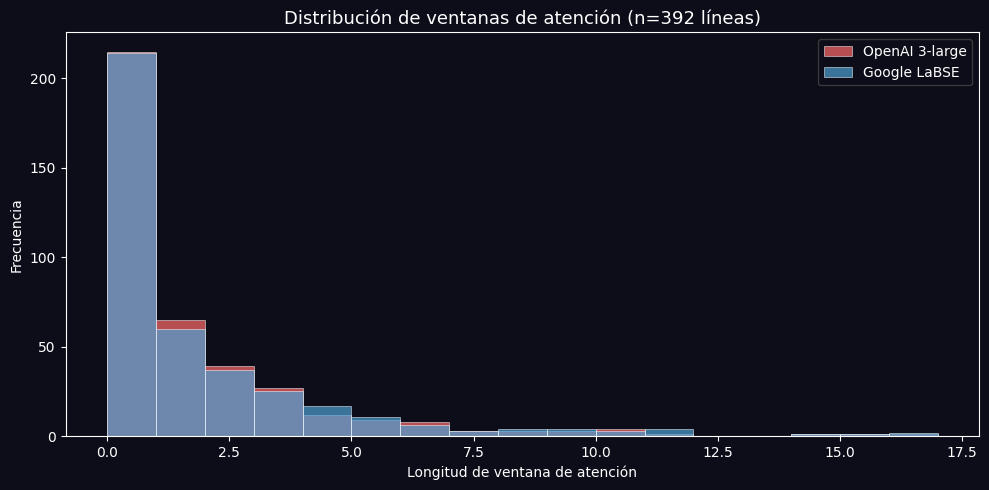

In [49]:
# Visualización: distribución de ventanas
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, max(merged_w["window_oa"].max(), merged_w["window_lb"].max())+2)
ax.hist(merged_w["window_oa"], bins=bins, alpha=0.7, label="OpenAI 3-large",
         color="#ff6b6b", edgecolor="white", linewidth=0.5)
ax.hist(merged_w["window_lb"], bins=bins, alpha=0.7, label="Google LaBSE",
         color="#4ea1d3", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Longitud de ventana de atención")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de ventanas de atención (n=392 líneas)", color="white", fontsize=13)
ax.legend(facecolor="#0d0d1a", labelcolor="white", edgecolor="#444")
plt.tight_layout()
plt.show()


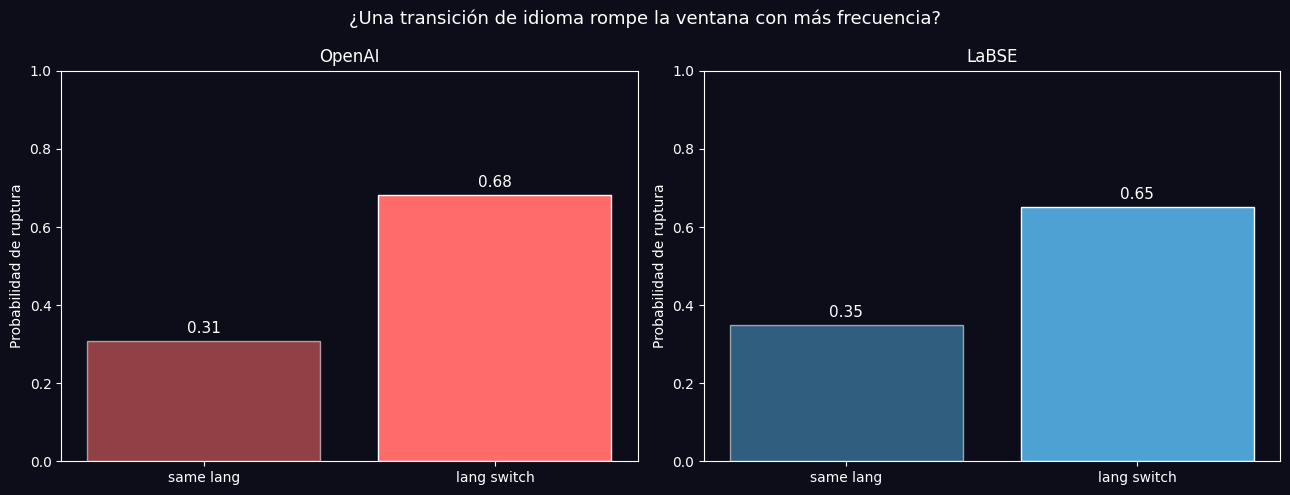

In [50]:
# Tasa de ruptura: same lang vs lang switch
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, df, c) in zip(axes, [("OpenAI", tr_oa, "#ff6b6b"),
                                     ("LaBSE",  tr_lb, "#4ea1d3")]):
    same = df[df["transition"]=="same"]["broken"].mean()
    sw   = df[df["transition"]=="switch"]["broken"].mean()
    bars = ax.bar(["same lang", "lang switch"], [same, sw], color=c, edgecolor="white")
    bars[0].set_alpha(0.55); bars[1].set_alpha(1.0)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Probabilidad de ruptura"); ax.set_title(name, color="white")
    ax.set_facecolor("#0d0d1a")
    for j, v in enumerate([same, sw]):
        ax.text(j, v+0.02, f"{v:.2f}", ha="center", color="white", fontsize=11)
plt.suptitle("¿Una transición de idioma rompe la ventana con más frecuencia?",
              color="white", fontsize=13)
plt.tight_layout()
plt.show()


### Resultados clave

| Resultado | Hallazgo |
|---|---|
| Spearman OpenAI ↔ LaBSE | ρ ≈ 0.64 (moderado, no fuerte) |
| Ventana media | OpenAI 1.36 · LaBSE 1.51 (LaBSE ~10% más larga) |
| **Tasa de ruptura OpenAI** | same-lang **0.36** → switch **0.70** (Δ=+0.34) |
| **Tasa de ruptura LaBSE** | same-lang **0.41** → switch **0.65** (Δ=+0.24) |

**Conclusión empírica:**

1. **AMBOS modelos confunden cambio de idioma con cambio de tema** — la tasa de ruptura casi se duplica en transiciones lingüísticas, sin que el tema necesariamente cambie.
2. **LaBSE es 30% menos reactivo al switch** que OpenAI. Su entrenamiento con corpus paralelo atenúa el sesgo, pero no lo elimina.
3. **Esto valida — sobre datos reales y multilingües — el problema señalado en el post anterior** (Beatles vs Floyd): los embeddings distribucionales miden continuidad léxica, no conceptual. Aquamosh, por ser cuadrilingüe, lo hace falsable.

> *El álbum no es un objeto de estudio — es un dispositivo crítico de la herramienta de medición.*

Ver `THEORETICAL_FRAMEWORK.md` para el desarrollo completo del argumento.


---

## Cierre

Si todo corrió correctamente, este notebook contiene:

- **12 letras** desde Genius (con cache)
- **~2,000+ comentarios** de YouTube por track
- **Crítica especializada** scrapeada
- **Dos modelos de embedding** que se chequean entre sí (OpenAI + Gemini)
- **Una prueba estadística central** (chi² idioma × campo)
- **Un mapa cultural 2D** del álbum
- **Una síntesis interpretativa** escrita por Gemini 2.5 Pro a partir de los datos

El blog post irá en `content/post/2026-05-20-aquamosh-anatomia-cuadrilingue.md`
y usará la `final_synthesis` como punto de partida narrativo, no como producto final.

> *Si los datos dicen otra cosa que la tesis, el blog post lo dirá. Esa es la
> diferencia entre análisis y publicidad.*
